# EfficientNet like Solo Deepfake Detector

## ОЗНАКОМЛЕНИЕ ПЕРЕД ПРОЧТЕНИЕМ
Это решения появилось, когда я понял, что мой сильный ансмабль из 4 моделей уже достиг зоны насыщения, а дальнейший тюнинг явно ведет к подбору под валидацию и ни к чему не приведет. По этому у меня возникла идея взять модель из лучшего ядра моего ансамбля то есть EfficientNetB3 и доработать ее, не только архитектурно, но и обучить ее под OOF, чтобы каждая картинка была как train и как val, тем самым я смог получить честную оценку модели. Также в подоходе с ансамблями у нас не было обучения на всем датасете, в этом блокноте я воплатил и эту идею

Модель принимает RGB-изображение размером `384x384` и возвращает один logit.  
Вероятность класса `fake` считается через `sigmoid`.

---

## Архитектура модели

Используется кастомная EfficientNetV-подобная архитектура,  `efficientnetv5`.

Основные блоки модели:

- `ConvBnAct` — сверточный блок с BatchNorm и SiLU;
- `EdgeResidual` — fused-MBConv-подобный блок;
- `InvertedResidual` — MBConv-блок с depthwise convolution;
- `Squeeze-and-Excitation` — переоценка важности каналов;
- `DropPath` — stochastic depth для регуляризации.

Схема модели:

    Входное изображение
    [B, 3, 384, 384]
            |
            v
    Conv Stem
    Conv2d: 3 -> 24
    BatchNorm2d
    SiLU
            |
            v
    Stage 1
    ConvBnAct x 2
    channels: 24 -> 24
            |
            v
    Stage 2
    EdgeResidual x 4
    channels: 24 -> 48
            |
            v
    Stage 3
    EdgeResidual x 4
    channels: 48 -> 64
            |
            v
    Stage 4
    InvertedResidual x 6
    channels: 64 -> 128
    Squeeze-and-Excitation
            |
            v
    Stage 5
    InvertedResidual x 9
    channels: 128 -> 160
    Squeeze-and-Excitation
            |
            v
    Stage 6
    InvertedResidual x 15
    channels: 160 -> 256
    Squeeze-and-Excitation
            |
            v
    Conv Head
    Conv2d: 256 -> 1280
    BatchNorm2d
    SiLU
            |
            v
    AdaptiveAvgPool2d(1, 1)
            |
            v
    Flatten
            |
            v
    Classification Head
    BatchNorm1d
    Dropout
    Linear: 1280 -> 512
    GELU
    BatchNorm1d
    Dropout
    Linear: 512 -> 1
            |
            v
    Output logit
    [B, 1]

Параметры модели:

    image_size = 384
    drop_rate = 0.30
    drop_path_rate = 0.20
    output_classes = 1

---

## Аугментации

Для обучения используются аугментации, направленные на устойчивость к изменению масштаба, сжатию, шуму, блюру и локальным искажениям.

Train-аугментации:

    RandomResizedCrop 384x384
    scale = (0.86, 1.0)
    ratio = (0.95, 1.05)

    HorizontalFlip(p=0.50)
    VerticalFlip(p=0.04)

    ShiftScaleRotate
    shift_limit = 0.035
    scale_limit = 0.10
    rotate_limit = 12
    p = 0.35

    OneOf:
        ImageCompression quality 35-92
        Downscale
    p = 0.45

    OneOf:
        GaussianBlur
        MotionBlur
        MedianBlur
    p = 0.22

    OneOf:
        GaussNoise
        ISONoise
    p = 0.22

    OneOf:
        RandomBrightnessContrast
        HueSaturationValue
        RGBShift
        CLAHE
    p = 0.33

    CoarseDropout(p=0.16)

    Normalize ImageNet mean/std
    ToTensorV2

Дополнительно во время обучения используются:

    Salt-and-pepper overlay
    probability = 0.30

    SBI-like augmentation
    probability растет от 0.02 до 0.15

Validation обработка:

    Resize 384x384
    Normalize ImageNet mean/std
    ToTensorV2

---

## Обучение

Для обучения используется 5-fold OOF-схема.

Основные параметры:

    folds = 5
    epochs = 60
    batch_size = 16
    accumulation_steps = 4
    val_batch_size = 64

Loss:

    Focal Loss
    alpha = 0.75
    gamma = 2.0
    label_smoothing = 0.03

Оптимизатор:

    AdamW
    backbone_lr = 3e-4
    head_lr = 6e-4
    weight_decay = 2e-2

Scheduler:

    Warmup + Cosine LR

Также используются:

    EMA
    MixUp / CutMix
    WeightedRandomSampler
    hard negative mining
    gradient clipping max_norm = 1.0
    AMP
    channels_last

После OOF-обучения выбирается лучший fold, затем модель дообучается на полном train-датасете.

---

## Инференс

Модель возвращает один logit.

Вероятность класса `fake` считается так:

    prob = torch.sigmoid(logit)

Финальное предсказание получается сравнением вероятности с threshold:

    pred = prob >= threshold

Threshold выбирается по OOF-предсказаниям.

Для финального инференса используется TTA из 8 вариантов:

    1. Обычный resize
    2. HorizontalFlip
    3. VerticalFlip
    4. HorizontalFlip + VerticalFlip
    5. Resize 1.10 + CenterCrop
    6. Resize 1.15 + CenterCrop + HorizontalFlip
    7. Rotate +5 degrees
    8. Rotate -5 degrees

Logits со всех TTA-вариантов усредняются, после этого применяется sigmoid и threshold.

Финальный submission сохраняется в формате:

    Id,target_feature

# Подготовка и загрузка данных

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", e)


Mounted at /content/drive


In [ ]:
import os

In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/


In [ ]:
!unzip -q /content/drive/MyDrive/YAN/test_images.zip -d /content/

In [ ]:
print(os.listdir("/content"))
print(len(os.listdir("/content/train_images")), len(os.listdir("/content/test_images")))

['.config', 'train_images', 'drive', 'test_images', 'sample_data']
50000 10000


# Подключение библиотек

In [ ]:

import os
import gc
import json
import math
import random
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Optional, Tuple, Dict, List

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix

import albumentations as A
from albumentations.pytorch import ToTensorV2

cv2.setNumThreads(0)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


# CONFIG FULL TRAINING

In [ ]:
class CFG:
    TRAIN_IMG_DIR = "/content/train_images"
    TEST_IMG_DIR  = "/content/test_images"
    LABELS_CSV    = "/content/drive/MyDrive/YAN/train_solution.csv"
    SAVE_DIR      = "/content/drive/MyDrive/YAN"

    EXP_NAME = "effv2s_384_solo_finetune_oof_fullfit_a100"
    OUT_DIR = str(Path(SAVE_DIR) / EXP_NAME)

    SEED = 42
    POSITIVE_LABEL = 1
    NEGATIVE_LABEL = 0
    SUBMISSION_ID_COL = "Id"

    # ===== Model =====
    MODEL_NAME = "efficientnetv5"
    IMG_SIZE = 384
    DROP_RATE = 0.30
    DROP_PATH_RATE = 0.20
    USE_GRAD_CHECKPOINT = False
    CHANNELS_LAST = True

    # ===== OOF k-fold stage =====
    RUN_KFOLD_OOF = True
    N_FOLDS = 5
    TRAIN_FOLDS = [0, 1, 2, 3, 4]
    EPOCHS = 60
    EARLY_STOP_PATIENCE = 12
    EARLY_STOP_MIN_DELTA = 0.00010
    OOF_TTA_AFTER_FOLD = True

    TRAIN_FINAL_FULLFIT = True
    FULLFIT_INIT_FROM_BEST_FOLD = True
    FULLFIT_EPOCHS = 10
    FULLFIT_LR_MULT = 0.35
    FULLFIT_SBI_MULT = 0.50
    FULLFIT_MIXUP_MULT = 0.50

    PHYSICAL_BATCH = 16
    ACCUMULATION_STEPS = 4
    VAL_BATCH = 64
    NUM_WORKERS = 12
    LR_BACKBONE = 3.0e-4
    LR_HEAD = 6.0e-4
    WEIGHT_DECAY = 2.0e-2
    WARMUP_EPOCHS = 4.0
    MIN_LR_RATIO = 0.025
    GRAD_CLIP_NORM = 1.0
    EMA_DECAY = 0.9995
    AMP = True

    LOSS_TYPE = "focal"
    FOCAL_ALPHA = 0.75
    FOCAL_GAMMA = 2.0
    LABEL_SMOOTHING = 0.03
    USE_POS_WEIGHT_IN_BCE = False
    USE_WEIGHTED_SAMPLER = True

    MIXUP_ALPHA = 0.25
    CUTMIX_ALPHA = 1.00
    MIXUP_PROB = 0.35
    MIXUP_START_EPOCH = 5
    MIXUP_OFF_LAST_EPOCHS = 8

    USE_HNM = True
    HNM_START_EPOCH = 10
    HNM_RATIO_START = 1.10
    HNM_RATIO_END = 1.55
    HNM_MIN_NEG_KEEP = 24

    SP_NOISE_PROB = 0.30
    SP_AMOUNT_RANGE = (0.001, 0.020)
    SP_SALT_VS_PEPPER_RANGE = (0.25, 0.75)

    SBI_ENABLED = True
    SBI_PROB_START = 0.02
    SBI_PROB_END = 0.15
    SBI_RAMP_EPOCHS = 12

    NUM_THRESHOLDS = 2001
    MIN_RECALL_FOR_THRESHOLD = None
    TTA_BATCH = 16
    TTA_N = 8
    THRESHOLD_MODE = "oof"
    MANUAL_THRESHOLD = None
    SAVE_ALTERNATIVE_SUBMISSIONS = True

Path(CFG.OUT_DIR).mkdir(parents=True, exist_ok=True)
print("Output dir:", CFG.OUT_DIR)


Output dir: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100


# Конфигурация эксперимента

In [ ]:

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(CFG.SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1))



Device: cuda
GPU: Tesla T4
VRAM GB: 14.6


# Загрузка и проверка данных

In [ ]:

def load_train_dataframe(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    lower = {str(c).lower(): c for c in df.columns}
    if "id" not in lower or "target_feature" not in lower:
        df = pd.read_csv(csv_path, header=None, names=["Id", "target_feature"])
    else:
        df = df.rename(columns={lower["id"]: "Id", lower["target_feature"]: "target_feature"})

    df = df[["Id", "target_feature"]].copy()
    df["Id"] = df["Id"].astype(str)
    df["target_feature"] = df["target_feature"].astype(int)
    return df


def load_test_dataframe(test_dir: str) -> pd.DataFrame:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    paths = [p for p in Path(test_dir).iterdir() if p.suffix.lower() in exts]
    if not paths:
        raise FileNotFoundError(f"No test images found in {test_dir}")

    def key_fn(p: Path):
        return int(p.stem) if p.stem.isdigit() else p.stem

    ids = [p.stem for p in sorted(paths, key=key_fn)]
    return pd.DataFrame({"Id": ids})


def build_stem_to_path(img_dir: str) -> Dict[str, Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    base = Path(img_dir)
    mapping = {p.stem: p for p in base.iterdir() if p.is_file() and p.suffix.lower() in exts}
    if not mapping:
        raise FileNotFoundError(f"No images found in {img_dir}")
    return mapping


def find_image_path(img_dir: str, image_id: str) -> Path:
    base = Path(img_dir)
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        p = base / f"{image_id}{ext}"
        if p.exists():
            return p
    matches = list(base.glob(f"{image_id}.*"))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Image not found for Id={image_id} in {img_dir}")


df = load_train_dataframe(CFG.LABELS_CSV)
print(df.head())
print("Total:", len(df))
print(df["target_feature"].value_counts().sort_index())
neg = int((df["target_feature"] == 0).sum())
pos = int((df["target_feature"] == 1).sum())
print(f"neg={neg}, pos={pos}, neg/pos={neg/max(pos,1):.3f}, fake_ratio={pos/len(df):.4f}")

assert Path(CFG.TRAIN_IMG_DIR).exists(), CFG.TRAIN_IMG_DIR
assert Path(CFG.TEST_IMG_DIR).exists(), CFG.TEST_IMG_DIR


  Id  target_feature
0  0               0
1  1               1
2  2               1
3  3               0
4  4               0
Total: 50000
target_feature
0    41500
1     8500
Name: count, dtype: int64
neg=41500, pos=8500, neg/pos=4.882, fake_ratio=0.1700


# Аугментация данных

In [ ]:

def aug_random_resized_crop(size: int, scale=(0.86, 1.0), p=1.0):
    try:
        return A.RandomResizedCrop(size=(size, size), scale=scale, ratio=(0.95, 1.05), p=p)
    except TypeError:
        return A.RandomResizedCrop(height=size, width=size, scale=scale, ratio=(0.95, 1.05), p=p)


def aug_image_compression(qmin=45, qmax=95, p=1.0):
    try:
        return A.ImageCompression(quality_range=(qmin, qmax), p=p)
    except TypeError:
        return A.ImageCompression(quality_lower=qmin, quality_upper=qmax, p=p)


def aug_downscale(p=1.0):
    try:
        return A.Downscale(
            scale_range=(0.45, 0.82),
            interpolation_pair={"downscale": cv2.INTER_AREA, "upscale": cv2.INTER_LINEAR},
            p=p,
        )
    except TypeError:
        return A.Downscale(scale_min=0.45, scale_max=0.82, interpolation=cv2.INTER_LINEAR, p=p)


def aug_gauss_noise(p=1.0):
    try:
        return A.GaussNoise(std_range=(0.005, 0.055), p=p)
    except TypeError:
        return A.GaussNoise(var_limit=(4.0, 120.0), p=p)


def aug_coarse_dropout(size: int, p=0.16):
    h_small = max(8, int(size * 0.04))
    h_large = max(16, int(size * 0.16))
    try:
        return A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(h_small, h_large),
            hole_width_range=(h_small, h_large),
            fill=0,
            p=p,
        )
    except TypeError:
        return A.CoarseDropout(
            min_holes=1, max_holes=3,
            min_height=h_small, max_height=h_large,
            min_width=h_small, max_width=h_large,
            fill_value=0,
            p=p,
        )


def norm_tfm():
    return A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))


def get_train_transforms(img_size: int) -> A.Compose:
    return A.Compose([
        aug_random_resized_crop(img_size, scale=(0.86, 1.0), p=1.0),
        A.HorizontalFlip(p=0.50),
        A.VerticalFlip(p=0.04),
        A.ShiftScaleRotate(
            shift_limit=0.035, scale_limit=0.10, rotate_limit=12,
            border_mode=cv2.BORDER_REFLECT_101, p=0.35,
        ),
        A.OneOf([
            aug_image_compression(35, 92, p=1.0),
            aug_downscale(p=1.0),
        ], p=0.45),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=(3, 7), p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
        ], p=0.22),
        A.OneOf([
            aug_gauss_noise(p=1.0),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.08, 0.35), p=1.0),
        ], p=0.22),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=1.0),
            A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=14, val_shift_limit=12, p=1.0),
            A.RGBShift(r_shift_limit=8, g_shift_limit=8, b_shift_limit=8, p=1.0),
            A.CLAHE(clip_limit=3.0, p=1.0),
        ], p=0.33),
        aug_coarse_dropout(img_size, p=0.16),
        norm_tfm(),
        ToTensorV2(),
    ])


def get_val_transforms(img_size: int) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),
        norm_tfm(),
        ToTensorV2(),
    ])


def rotate_fixed(degrees: float):
    try:
        return A.Rotate(limit=(degrees, degrees), border_mode=cv2.BORDER_REFLECT_101, p=1.0)
    except TypeError:
        return A.ShiftScaleRotate(shift_limit=0, scale_limit=0, rotate_limit=(degrees, degrees), border_mode=cv2.BORDER_REFLECT_101, p=1.0)


def get_tta_transforms(img_size: int) -> List[A.Compose]:
    return [
        A.Compose([A.Resize(img_size, img_size), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size), A.HorizontalFlip(p=1.0), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size), A.VerticalFlip(p=1.0), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size), A.HorizontalFlip(p=1.0), A.VerticalFlip(p=1.0), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(int(img_size * 1.10), int(img_size * 1.10)), A.CenterCrop(img_size, img_size), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(int(img_size * 1.15), int(img_size * 1.15)), A.CenterCrop(img_size, img_size), A.HorizontalFlip(p=1.0), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size), rotate_fixed(+5.0), norm_tfm(), ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size), rotate_fixed(-5.0), norm_tfm(), ToTensorV2()]),
    ]


# Конвейеры данных и стратегии по борьбе с генерации артефактов

In [ ]:

def add_salt_pepper_overlay(image: np.ndarray, amount_range=CFG.SP_AMOUNT_RANGE, svp_range=CFG.SP_SALT_VS_PEPPER_RANGE) -> np.ndarray:
    out = image.copy()
    h, w = out.shape[:2]
    amount = float(np.random.uniform(amount_range[0], amount_range[1]))
    salt_vs_pepper = float(np.random.uniform(svp_range[0], svp_range[1]))
    n_total = int(amount * h * w)
    if n_total <= 0:
        return out

    n_salt = int(n_total * salt_vs_pepper)
    n_pepper = n_total - n_salt
    if n_salt > 0:
        ys = np.random.randint(0, h, size=n_salt)
        xs = np.random.randint(0, w, size=n_salt)
        out[ys, xs] = 255
    if n_pepper > 0:
        ys = np.random.randint(0, h, size=n_pepper)
        xs = np.random.randint(0, w, size=n_pepper)
        out[ys, xs] = 0
    return out


def apply_sbi_like(image: np.ndarray) -> np.ndarray:
    h, w = image.shape[:2]
    if h < 64 or w < 64:
        return image

    patch_w = int(np.random.uniform(0.28, 0.56) * w)
    patch_h = int(np.random.uniform(0.28, 0.56) * h)
    patch_w = max(24, min(w - 2, patch_w))
    patch_h = max(24, min(h - 2, patch_h))
    x1 = np.random.randint(0, w - patch_w + 1)
    y1 = np.random.randint(0, h - patch_h + 1)
    x2, y2 = x1 + patch_w, y1 + patch_h

    src = image[y1:y2, x1:x2].copy()
    if np.random.rand() < 0.5:
        src = cv2.flip(src, 1)
    if np.random.rand() < 0.75:
        scale = float(np.random.uniform(0.42, 0.82))
        dw, dh = max(8, int(patch_w * scale)), max(8, int(patch_h * scale))
        src = cv2.resize(src, (dw, dh), interpolation=cv2.INTER_AREA)
        src = cv2.resize(src, (patch_w, patch_h), interpolation=cv2.INTER_LINEAR)
    if np.random.rand() < 0.60:
        src = cv2.GaussianBlur(src, (3, 3), sigmaX=float(np.random.uniform(0.2, 1.2)))

    gain = float(np.random.uniform(0.86, 1.14))
    bias = float(np.random.uniform(-14.0, 14.0))
    src = np.clip(src.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)

    mask = np.zeros((patch_h, patch_w), dtype=np.float32)
    cx = np.random.randint(patch_w // 3, max(patch_w // 3 + 1, patch_w - patch_w // 3))
    cy = np.random.randint(patch_h // 3, max(patch_h // 3 + 1, patch_h - patch_h // 3))
    ax = max(8, int(patch_w * np.random.uniform(0.25, 0.55)))
    ay = max(8, int(patch_h * np.random.uniform(0.25, 0.55)))
    angle = float(np.random.uniform(0, 180))
    cv2.ellipse(mask, (cx, cy), (ax, ay), angle, 0, 360, color=1.0, thickness=-1)
    blur_k = int(np.random.choice([5, 7, 9, 11]))
    mask = cv2.GaussianBlur(mask, (blur_k, blur_k), sigmaX=0)
    alpha = float(np.random.uniform(0.58, 0.90))
    mask = np.clip(mask * alpha, 0.0, 1.0)[..., None]

    dst = image[y1:y2, x1:x2].astype(np.float32)
    mixed = mask * src.astype(np.float32) + (1.0 - mask) * dst
    out = image.copy()
    out[y1:y2, x1:x2] = np.clip(mixed, 0, 255).astype(np.uint8)
    return out


class DeepfakeDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        img_dir: str,
        transform: A.Compose,
        has_labels: bool = True,
        train_mode: bool = False,
        sbi_prob: float = 0.0,
        sp_noise_prob: float = 0.0,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = has_labels
        self.train_mode = train_mode
        self.sbi_prob = float(sbi_prob)
        self.sp_noise_prob = float(sp_noise_prob)
        self.stem_to_path = build_stem_to_path(img_dir)

    def set_sbi_prob(self, p: float) -> None:
        self.sbi_prob = float(max(0.0, min(1.0, p)))

    def __len__(self):
        return len(self.df)

    def _read_rgb(self, image_id: str) -> np.ndarray:
        p = self.stem_to_path.get(str(image_id))
        if p is None:
            raise FileNotFoundError(f"Image not found for Id={image_id} in {self.img_dir}")
        image = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Failed to read image: {p}")
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["Id"])
        image = self._read_rgb(image_id)

        if self.has_labels:
            label = float(row["target_feature"])
            if self.train_mode and CFG.SBI_ENABLED and label == 0.0 and np.random.rand() < self.sbi_prob:
                image = apply_sbi_like(image)
                label = 1.0
            if self.train_mode and np.random.rand() < self.sp_noise_prob:
                image = add_salt_pepper_overlay(image)

            image = self.transform(image=image)["image"]
            return image, torch.tensor([label], dtype=torch.float32)

        image = self.transform(image=image)["image"]
        return image, image_id


class TTADataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, img_dir: str, tta_transforms: List[A.Compose], has_labels: bool = False):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.tta_transforms = tta_transforms
        self.has_labels = has_labels
        self.stem_to_path = build_stem_to_path(img_dir)

    def __len__(self):
        return len(self.df)

    def _read_rgb(self, image_id: str) -> np.ndarray:
        p = self.stem_to_path.get(str(image_id))
        if p is None:
            raise FileNotFoundError(f"Image not found for Id={image_id} in {self.img_dir}")
        image = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Failed to read image: {p}")
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["Id"])
        image = self._read_rgb(image_id)
        images = [tfm(image=image)["image"] for tfm in self.tta_transforms]
        stack = torch.stack(images, dim=0)
        if self.has_labels:
            return stack, torch.tensor([float(row["target_feature"])], dtype=torch.float32), image_id
        return stack, image_id


# Архитектура EfficientNetV5

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def drop_path(x: torch.Tensor, drop_prob: float = 0.0, training: bool = False) -> torch.Tensor:
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor


class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return drop_path(x, self.drop_prob, self.training)


def _tf_same_pad(x: torch.Tensor, kernel_size, stride, dilation) -> torch.Tensor:
    if isinstance(kernel_size, tuple):
        kh, kw = kernel_size
    else:
        kh = kw = int(kernel_size)

    if isinstance(stride, tuple):
        sh, sw = stride
    else:
        sh = sw = int(stride)

    if isinstance(dilation, tuple):
        dh, dw = dilation
    else:
        dh = dw = int(dilation)

    ih, iw = x.shape[-2:]
    oh = math.ceil(ih / sh)
    ow = math.ceil(iw / sw)

    pad_h = max((oh - 1) * sh + (kh - 1) * dh + 1 - ih, 0)
    pad_w = max((ow - 1) * sw + (kw - 1) * dw + 1 - iw, 0)

    if pad_h > 0 or pad_w > 0:
        x = F.pad(
            x,
            [
                pad_w // 2,
                pad_w - pad_w // 2,
                pad_h // 2,
                pad_h - pad_h // 2,
            ],
        )
    return x


class Conv2dSame(nn.Conv2d):

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = _tf_same_pad(x, self.kernel_size, self.stride, self.dilation)
        return F.conv2d(
            x,
            self.weight,
            self.bias,
            self.stride,
            padding=(0, 0),
            dilation=self.dilation,
            groups=self.groups,
        )


class SqueezeExcite(nn.Module):
    def __init__(self, in_chs: int, rd_chs: int):
        super().__init__()
        self.conv_reduce = nn.Conv2d(in_chs, rd_chs, kernel_size=1, bias=True)
        self.act1 = nn.SiLU(inplace=True)
        self.conv_expand = nn.Conv2d(rd_chs, in_chs, kernel_size=1, bias=True)
        self.gate = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s = x.mean((2, 3), keepdim=True)
        s = self.conv_reduce(s)
        s = self.act1(s)
        s = self.conv_expand(s)
        return x * self.gate(s)


class ConvBnAct(nn.Module):
    def __init__(
        self,
        in_chs: int,
        out_chs: int,
        kernel_size: int = 3,
        stride: int = 1,
        skip: bool = False,
        drop_path_rate: float = 0.0,
        bn_eps: float = 1e-3,
        bn_momentum: float = 0.1,
    ):
        super().__init__()
        self.conv = Conv2dSame(
            in_chs,
            out_chs,
            kernel_size=kernel_size,
            stride=stride,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_chs, eps=bn_eps, momentum=bn_momentum)
        self.act1 = nn.SiLU(inplace=True)

        self.has_skip = bool(skip and stride == 1 and in_chs == out_chs)
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shortcut = x

        x = self.conv(x)
        x = self.bn1(x)
        x = self.act1(x)

        if self.has_skip:
            x = self.drop_path(x) + shortcut
        return x


class EdgeResidual(nn.Module):

    def __init__(
        self,
        in_chs: int,
        out_chs: int,
        exp_chs: int,
        exp_kernel_size: int = 3,
        stride: int = 1,
        drop_path_rate: float = 0.0,
        bn_eps: float = 1e-3,
        bn_momentum: float = 0.1,
    ):
        super().__init__()

        self.conv_exp = Conv2dSame(
            in_chs,
            exp_chs,
            kernel_size=exp_kernel_size,
            stride=stride,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(exp_chs, eps=bn_eps, momentum=bn_momentum)
        self.act1 = nn.SiLU(inplace=True)

        self.conv_pwl = nn.Conv2d(exp_chs, out_chs, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_chs, eps=bn_eps, momentum=bn_momentum)

        self.has_skip = stride == 1 and in_chs == out_chs
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shortcut = x

        x = self.conv_exp(x)
        x = self.bn1(x)
        x = self.act1(x)

        x = self.conv_pwl(x)
        x = self.bn2(x)

        if self.has_skip:
            x = self.drop_path(x) + shortcut
        return x


class InvertedResidual(nn.Module):

    def __init__(
        self,
        in_chs: int,
        out_chs: int,
        exp_chs: int,
        se_rd_chs: int,
        dw_kernel_size: int = 3,
        stride: int = 1,
        drop_path_rate: float = 0.0,
        bn_eps: float = 1e-3,
        bn_momentum: float = 0.1,
    ):
        super().__init__()

        self.conv_pw = nn.Conv2d(in_chs, exp_chs, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(exp_chs, eps=bn_eps, momentum=bn_momentum)
        self.act1 = nn.SiLU(inplace=True)

        self.conv_dw = Conv2dSame(
            exp_chs,
            exp_chs,
            kernel_size=dw_kernel_size,
            stride=stride,
            groups=exp_chs,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(exp_chs, eps=bn_eps, momentum=bn_momentum)
        self.act2 = nn.SiLU(inplace=True)

        self.se = SqueezeExcite(exp_chs, se_rd_chs)

        self.conv_pwl = nn.Conv2d(exp_chs, out_chs, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_chs, eps=bn_eps, momentum=bn_momentum)

        self.has_skip = stride == 1 and in_chs == out_chs
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shortcut = x

        x = self.conv_pw(x)
        x = self.bn1(x)
        x = self.act1(x)

        x = self.conv_dw(x)
        x = self.bn2(x)
        x = self.act2(x)

        x = self.se(x)

        x = self.conv_pwl(x)
        x = self.bn3(x)

        if self.has_skip:
            x = self.drop_path(x) + shortcut
        return x


def _init_weight_goog_like_timm(m: nn.Module) -> None:
    if isinstance(m, nn.Conv2d):
        fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
        fan_out //= m.groups
        nn.init.normal_(m.weight, 0.0, math.sqrt(2.0 / fan_out))
        if m.bias is not None:
            nn.init.zeros_(m.bias)

    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)


class EfficientNetV2SBackboneNoTimm(nn.Module):

    num_features = 1280

    def __init__(
        self,
        drop_path_rate: float = 0.2,
        bn_eps: float = 1e-3,
        bn_momentum: float = 0.1,
    ):
        super().__init__()

        self.grad_checkpointing = False

        self.conv_stem = Conv2dSame(3, 24, kernel_size=3, stride=2, bias=False)
        self.bn1 = nn.BatchNorm2d(24, eps=bn_eps, momentum=bn_momentum)
        self.act1 = nn.SiLU(inplace=True)

        depths = [2, 4, 4, 6, 9, 15]
        total_blocks = sum(depths)

        dpr = [drop_path_rate * i / total_blocks for i in range(total_blocks)]
        bi = 0

        blocks = []

        stage = []
        stage.append(
            ConvBnAct(
                24,
                24,
                kernel_size=3,
                stride=1,
                skip=True,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        stage.append(
            ConvBnAct(
                24,
                24,
                kernel_size=3,
                stride=1,
                skip=True,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        blocks.append(nn.Sequential(*stage))

        stage = []
        stage.append(
            EdgeResidual(
                24,
                48,
                exp_chs=96,
                exp_kernel_size=3,
                stride=2,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        for _ in range(3):
            stage.append(
                EdgeResidual(
                    48,
                    48,
                    exp_chs=192,
                    exp_kernel_size=3,
                    stride=1,
                    drop_path_rate=dpr[bi],
                    bn_eps=bn_eps,
                    bn_momentum=bn_momentum,
                )
            )
            bi += 1
        blocks.append(nn.Sequential(*stage))

        stage = []
        stage.append(
            EdgeResidual(
                48,
                64,
                exp_chs=192,
                exp_kernel_size=3,
                stride=2,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        for _ in range(3):
            stage.append(
                EdgeResidual(
                    64,
                    64,
                    exp_chs=256,
                    exp_kernel_size=3,
                    stride=1,
                    drop_path_rate=dpr[bi],
                    bn_eps=bn_eps,
                    bn_momentum=bn_momentum,
                )
            )
            bi += 1
        blocks.append(nn.Sequential(*stage))

        stage = []
        stage.append(
            InvertedResidual(
                64,
                128,
                exp_chs=256,
                se_rd_chs=16,
                dw_kernel_size=3,
                stride=2,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        for _ in range(5):
            stage.append(
                InvertedResidual(
                    128,
                    128,
                    exp_chs=512,
                    se_rd_chs=32,
                    dw_kernel_size=3,
                    stride=1,
                    drop_path_rate=dpr[bi],
                    bn_eps=bn_eps,
                    bn_momentum=bn_momentum,
                )
            )
            bi += 1
        blocks.append(nn.Sequential(*stage))

        stage = []
        stage.append(
            InvertedResidual(
                128,
                160,
                exp_chs=768,
                se_rd_chs=32,
                dw_kernel_size=3,
                stride=1,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        for _ in range(8):
            stage.append(
                InvertedResidual(
                    160,
                    160,
                    exp_chs=960,
                    se_rd_chs=40,
                    dw_kernel_size=3,
                    stride=1,
                    drop_path_rate=dpr[bi],
                    bn_eps=bn_eps,
                    bn_momentum=bn_momentum,
                )
            )
            bi += 1
        blocks.append(nn.Sequential(*stage))

        stage = []
        stage.append(
            InvertedResidual(
                160,
                256,
                exp_chs=960,
                se_rd_chs=40,
                dw_kernel_size=3,
                stride=2,
                drop_path_rate=dpr[bi],
                bn_eps=bn_eps,
                bn_momentum=bn_momentum,
            )
        )
        bi += 1
        for _ in range(14):
            stage.append(
                InvertedResidual(
                    256,
                    256,
                    exp_chs=1536,
                    se_rd_chs=64,
                    dw_kernel_size=3,
                    stride=1,
                    drop_path_rate=dpr[bi],
                    bn_eps=bn_eps,
                    bn_momentum=bn_momentum,
                )
            )
            bi += 1
        blocks.append(nn.Sequential(*stage))

        assert bi == total_blocks

        self.blocks = nn.Sequential(*blocks)

        self.conv_head = nn.Conv2d(256, 1280, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(1280, eps=bn_eps, momentum=bn_momentum)
        self.act2 = nn.SiLU(inplace=True)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.apply(_init_weight_goog_like_timm)

    @torch.jit.ignore
    def set_grad_checkpointing(self, enable: bool = True) -> None:
        self.grad_checkpointing = bool(enable)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_stem(x)
        x = self.bn1(x)
        x = self.act1(x)

        if self.grad_checkpointing and self.training:
            from torch.utils.checkpoint import checkpoint

            for block_stage in self.blocks:
                x = checkpoint(block_stage, x, use_reentrant=False)
        else:
            x = self.blocks(x)

        x = self.conv_head(x)
        x = self.bn2(x)
        x = self.act2(x)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.global_pool(x).flatten(1)
        return x


class EfficientNetV2Solo(nn.Module):

    def __init__(self, model_name: str, drop_rate: float, drop_path_rate: float):
        super().__init__()

        self.requested_model_name = model_name
        self.used_model_name = model_name

        self.backbone = EfficientNetV2SBackboneNoTimm(
            drop_path_rate=drop_path_rate,
            bn_eps=1e-3,
            bn_momentum=0.1,
        )

        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(drop_rate),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(drop_rate * 0.5),
            nn.Linear(512, 1),
        )

        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        return self.head(features)


def build_model() -> nn.Module:
    model = EfficientNetV2Solo(
        model_name=CFG.MODEL_NAME,
        drop_rate=CFG.DROP_RATE,
        drop_path_rate=CFG.DROP_PATH_RATE,
    )

    if CFG.USE_GRAD_CHECKPOINT and hasattr(model.backbone, "set_grad_checkpointing"):
        model.backbone.set_grad_checkpointing(True)

    model = model.to(DEVICE)

    if CFG.CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)

    return model


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.0, pos_weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else torch.tensor([1.0]))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        if self.label_smoothing > 0:
            targets = targets * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        p_t = targets * probs + (1.0 - targets) * (1.0 - probs)
        alpha_t = targets * self.alpha + (1.0 - targets) * (1.0 - self.alpha)
        loss = alpha_t * (1.0 - p_t).pow(self.gamma) * bce
        return loss.mean()


class ModelEMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = float(decay)
        self.module = deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        msd = model.state_dict()
        for k, ema_v in self.module.state_dict().items():
            model_v = msd[k]
            if not ema_v.dtype.is_floating_point:
                ema_v.copy_(model_v)
            else:
                ema_v.mul_(self.decay).add_(model_v.detach(), alpha=1.0 - self.decay)


class WarmupCosineLR:
    def __init__(self, optimizer, total_steps: int, warmup_steps: int, min_lr_ratio: float):
        self.optimizer = optimizer
        self.total_steps = max(1, int(total_steps))
        self.warmup_steps = max(0, int(warmup_steps))
        self.min_lr_ratio = float(min_lr_ratio)
        self.base_lrs = [pg["lr"] for pg in optimizer.param_groups]
        self.step_num = 0

    def step(self):
        self.step_num += 1
        if self.warmup_steps > 0 and self.step_num <= self.warmup_steps:
            scale = self.step_num / self.warmup_steps
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
            scale = self.min_lr_ratio + (1.0 - self.min_lr_ratio) * cosine
        for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
            pg["lr"] = base_lr * scale

    def get_lr(self):
        return [pg["lr"] for pg in self.optimizer.param_groups]


def build_optimizer(model: nn.Module, lr_mult: float = 1.0):
    head_params, backbone_params = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if n.startswith("head"):
            head_params.append(p)
        else:
            backbone_params.append(p)
    return optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR_BACKBONE * lr_mult},
        {"params": head_params, "lr": CFG.LR_HEAD * lr_mult},
    ], weight_decay=CFG.WEIGHT_DECAY)


def build_criterion(pos_weight_value: float):
    pos_weight = None
    if CFG.USE_POS_WEIGHT_IN_BCE:
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    if CFG.LOSS_TYPE.lower() == "focal":
        return FocalLossWithLogits(
            alpha=CFG.FOCAL_ALPHA,
            gamma=CFG.FOCAL_GAMMA,
            label_smoothing=CFG.LABEL_SMOOTHING,
            pos_weight=pos_weight,
        )
    if CFG.LOSS_TYPE.lower() == "bce":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    raise ValueError(f"Unknown loss type: {CFG.LOSS_TYPE}")


# Вспомогательные алгоритмы обучения и оптимизации функций потерь

In [ ]:
def load_checkpoint_to_model(path: str, model: Optional[nn.Module] = None) -> nn.Module:
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    if model is None:
        model = build_model()
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()
    return model

In [ ]:

def class_weights_from_targets(y: np.ndarray) -> Tuple[float, np.ndarray]:
    y = np.asarray(y).astype(int)
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    if pos == 0 or neg == 0:
        return 1.0, np.ones(len(y), dtype=np.float64)
    pos_weight = neg / pos
    sample_weights = np.where(y == 1, pos_weight, 1.0).astype(np.float64)
    return float(pos_weight), sample_weights


def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def find_best_threshold(probs: np.ndarray, y_true: np.ndarray, min_recall: Optional[float] = None, n_thresholds: int = CFG.NUM_THRESHOLDS) -> Dict[str, float]:
    probs = np.asarray(probs)
    y_true = np.asarray(y_true).astype(int)
    best = {"threshold": 0.5, "f1": -1.0, "precision": 0.0, "recall": 0.0, "accuracy": 0.0}
    for thr in np.linspace(0.01, 0.99, n_thresholds):
        pred = (probs >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        p = precision_score(y_true, pred, zero_division=0)
        r = recall_score(y_true, pred, zero_division=0)
        acc = accuracy_score(y_true, pred)
        if min_recall is not None and r < min_recall:
            continue
        if (f1 > best["f1"] + 1e-12) or (np.isclose(f1, best["f1"]) and (r, p) > (best["recall"], best["precision"])):
            best = {"threshold": float(thr), "f1": float(f1), "precision": float(p), "recall": float(r), "accuracy": float(acc)}
    if best["f1"] < 0:
        pred = (probs >= 0.5).astype(int)
        best = {
            "threshold": 0.5,
            "f1": float(f1_score(y_true, pred, zero_division=0)),
            "precision": float(precision_score(y_true, pred, zero_division=0)),
            "recall": float(recall_score(y_true, pred, zero_division=0)),
            "accuracy": float(accuracy_score(y_true, pred)),
        }
    return best


def mixup_data(x, y, alpha: float):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, float(lam)


def cutmix_data(x, y, alpha: float):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1.0 - ((x2 - x1) * (y2 - y1) / float(W * H))
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, float(lam)


def soft_target_loss(criterion, pred, y_a, y_b, lam: float):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


def current_mixup_prob(epoch: int, total_epochs: int, base_prob: float) -> float:
    if epoch < CFG.MIXUP_START_EPOCH:
        return 0.0
    if epoch > total_epochs - CFG.MIXUP_OFF_LAST_EPOCHS:
        return 0.0
    return float(base_prob)


def current_sbi_prob(epoch: int, total_epochs: int, mult: float = 1.0) -> float:
    if not CFG.SBI_ENABLED:
        return 0.0
    ramp = min(1.0, max(0.0, (epoch - 1) / max(1, CFG.SBI_RAMP_EPOCHS)))
    p = CFG.SBI_PROB_START + ramp * (CFG.SBI_PROB_END - CFG.SBI_PROB_START)
    if epoch > total_epochs - CFG.MIXUP_OFF_LAST_EPOCHS:
        p *= 0.65
    return float(p * mult)


def current_hnm_ratio(epoch: int, total_epochs: int) -> float:
    t = min(1.0, max(0.0, (epoch - CFG.HNM_START_EPOCH) / max(1, total_epochs - CFG.HNM_START_EPOCH)))
    return float(CFG.HNM_RATIO_START + t * (CFG.HNM_RATIO_END - CFG.HNM_RATIO_START))


def hard_negative_mining_loss(logits: torch.Tensor, targets: torch.Tensor, criterion, hard_neg_ratio: float, min_neg_keep: int) -> torch.Tensor:
    logits_f = logits.view(-1)
    targets_f = targets.view(-1)
    raw = F.binary_cross_entropy_with_logits(logits_f, targets_f, reduction="none")
    pos_mask = targets_f > 0.5
    neg_mask = ~pos_mask
    pos_idx = torch.nonzero(pos_mask, as_tuple=False).view(-1)
    neg_idx = torch.nonzero(neg_mask, as_tuple=False).view(-1)
    if neg_idx.numel() == 0:
        return criterion(logits, targets)
    pos_count = int(pos_idx.numel())
    k = max(min_neg_keep, int(round(max(1, pos_count) * hard_neg_ratio)))
    k = min(k, neg_idx.numel())
    _, hard_local = torch.topk(raw[neg_idx], k=k, largest=True, sorted=False)
    keep_idx = neg_idx[hard_local] if pos_idx.numel() == 0 else torch.cat([pos_idx, neg_idx[hard_local]], dim=0)
    return criterion(logits_f[keep_idx].view(-1, 1), targets_f[keep_idx].view(-1, 1))


In [ ]:

def make_train_loader(train_df: pd.DataFrame, epochs: int, sbi_prob: float = 0.0, sp_noise_prob: float = CFG.SP_NOISE_PROB, fullfit: bool = False):
    ds = DeepfakeDataset(
        train_df,
        CFG.TRAIN_IMG_DIR,
        transform=get_train_transforms(CFG.IMG_SIZE),
        has_labels=True,
        train_mode=True,
        sbi_prob=sbi_prob,
        sp_noise_prob=sp_noise_prob,
    )
    y = train_df["target_feature"].values.astype(int)
    pos_weight, sample_weights = class_weights_from_targets(y)
    sampler = None
    shuffle = True
    if CFG.USE_WEIGHTED_SAMPLER:
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False
    loader = DataLoader(
        ds,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
        persistent_workers=CFG.NUM_WORKERS > 0,
    )
    return ds, loader, pos_weight


def make_val_loader(val_df: pd.DataFrame):
    ds = DeepfakeDataset(
        val_df,
        CFG.TRAIN_IMG_DIR,
        transform=get_val_transforms(CFG.IMG_SIZE),
        has_labels=True,
        train_mode=False,
    )
    loader = DataLoader(
        ds,
        batch_size=CFG.VAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=CFG.NUM_WORKERS > 0,
    )
    return loader


@torch.no_grad()
def collect_logits_targets(model: nn.Module, loader: DataLoader, desc: str = "val") -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    logits_all, targets_all = [], []
    for images, targets in tqdm(loader, desc=desc, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        if CFG.CHANNELS_LAST:
            images = images.contiguous(memory_format=torch.channels_last)
        targets = targets.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG.AMP and DEVICE.type == "cuda"):
            logits = model(images)
        logits_all.append(logits.detach().float().cpu().numpy().reshape(-1))
        targets_all.append(targets.detach().cpu().numpy().reshape(-1))
    return np.concatenate(logits_all), np.concatenate(targets_all).astype(int)


def train_one_epoch(model, ema, loader, optimizer, scheduler, scaler, criterion, epoch: int, total_epochs: int, base_mixup_prob: float, use_hnm: bool = True) -> float:
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)
    mix_prob = current_mixup_prob(epoch, total_epochs, base_mixup_prob)
    hnm_ratio = current_hnm_ratio(epoch, total_epochs)

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} train", leave=False)
    for step, (images, targets) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        if CFG.CHANNELS_LAST:
            images = images.contiguous(memory_format=torch.channels_last)

        apply_mix = (np.random.rand() < mix_prob)
        if apply_mix:
            if np.random.rand() < 0.5:
                images, y_a, y_b, lam = mixup_data(images, targets, CFG.MIXUP_ALPHA)
            else:
                images, y_a, y_b, lam = cutmix_data(images, targets, CFG.CUTMIX_ALPHA)

        with autocast(enabled=CFG.AMP and DEVICE.type == "cuda"):
            logits = model(images)
            if apply_mix:
                loss = soft_target_loss(criterion, logits, y_a, y_b, lam)
            elif use_hnm and CFG.USE_HNM and epoch >= CFG.HNM_START_EPOCH:
                loss = hard_negative_mining_loss(logits, targets, criterion, hnm_ratio, CFG.HNM_MIN_NEG_KEEP)
            else:
                loss = criterion(logits, targets)
            loss = loss / CFG.ACCUMULATION_STEPS

        scaler.scale(loss).backward()
        do_update = ((step + 1) % CFG.ACCUMULATION_STEPS == 0) or ((step + 1) == len(loader))
        if do_update:
            if CFG.GRAD_CLIP_NORM and CFG.GRAD_CLIP_NORM > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            ema.update(model)

        total_loss += loss.item() * images.size(0) * CFG.ACCUMULATION_STEPS
        lr0 = optimizer.param_groups[0]["lr"]
        pbar.set_postfix(loss=f"{loss.item()*CFG.ACCUMULATION_STEPS:.4f}", lr=f"{lr0:.2e}", mix=f"{mix_prob:.2f}", hnm=f"{hnm_ratio:.2f}")

    return total_loss / max(1, len(loader.dataset))


In [ ]:

from IPython.display import display, Image


def save_checkpoint(
    path: str,
    model: nn.Module,
    fold: Optional[int],
    epoch: int,
    metrics: Dict[str, float],
    model_used_name: str,
):
    ckpt = {
        "model_state_dict": model.state_dict(),
        "fold": fold,
        "epoch": epoch,
        "metrics": metrics,
        "threshold": metrics.get("threshold", 0.5),
        "best_f1": metrics.get("f1", None),
        "config": {
            "model_name": CFG.MODEL_NAME,
            "used_model_name": model_used_name,
            "img_size": CFG.IMG_SIZE,
            "drop_rate": CFG.DROP_RATE,
            "drop_path_rate": CFG.DROP_PATH_RATE,
        },
    }
    torch.save(ckpt, path)



def plot_fold_loss_f1(
    history,
    fold_dir,
    fold,
    save_name=None,
    show_in_notebook=True,
):
    if history is None or len(history) == 0:
        print("plot_fold_loss_f1: empty history")
        return None

    fold_dir = Path(fold_dir)
    fold_dir.mkdir(parents=True, exist_ok=True)

    if save_name is None:
        save_name = f"fold{fold}_loss_f1.png"

    save_path = fold_dir / save_name

    hist_df = pd.DataFrame(history)

    if "epoch" in hist_df.columns:
        epochs = hist_df["epoch"].astype(int).values
    else:
        epochs = np.arange(1, len(hist_df) + 1)

    loss_col = None
    for c in ["train_loss", "loss", "avg_train_loss"]:
        if c in hist_df.columns:
            loss_col = c
            break

    f1_col = None
    for c in ["f1", "val_f1", "best_f1", "valid_f1"]:
        if c in hist_df.columns:
            f1_col = c
            break

    if loss_col is None:
        raise ValueError(f"No train loss column found. History columns: {list(hist_df.columns)}")

    if f1_col is None:
        raise ValueError(f"No F1 column found. History columns: {list(hist_df.columns)}")

    loss_values = hist_df[loss_col].astype(float).values
    f1_values = hist_df[f1_col].astype(float).values

    best_loss_idx = int(np.nanargmin(loss_values))
    best_loss = float(loss_values[best_loss_idx])
    best_loss_epoch = int(epochs[best_loss_idx])

    best_f1_idx = int(np.nanargmax(f1_values))
    best_f1 = float(f1_values[best_f1_idx])
    best_f1_epoch = int(epochs[best_f1_idx])

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    fig.suptitle(
        f"Fold {fold} — Loss and F1",
        fontsize=20,
        fontweight="bold",
        y=1.02,
    )

    ax = axes[0]
    ax.plot(
        epochs,
        loss_values,
        marker="o",
        linewidth=2.5,
        markersize=7,
    )

    ax.set_title(
        f"Train Loss | best={best_loss:.4f} @ epoch {best_loss_epoch}",
        fontsize=15,
    )
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("Loss", fontsize=13)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=12)

    ax = axes[1]
    ax.plot(
        epochs,
        f1_values,
        marker="o",
        linewidth=2.5,
        markersize=7,
    )

    ax.set_title(
        f"Validation F1 | best={best_f1:.4f} @ epoch {best_f1_epoch}",
        fontsize=15,
    )
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("F1", fontsize=13)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=12)

    plt.tight_layout()

    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    if show_in_notebook:
        display(Image(filename=str(save_path)))

    return save_path


def train_single_fold(fold: int, train_df: pd.DataFrame, val_df: pd.DataFrame) -> Dict:
    fold_dir = Path(CFG.OUT_DIR) / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"FOLD {fold}: train={len(train_df)} val={len(val_df)}")
    print(
        f"train fake_ratio={train_df['target_feature'].mean():.4f}, "
        f"val fake_ratio={val_df['target_feature'].mean():.4f}"
    )
    print("=" * 80)

    train_ds, train_loader, pos_weight = make_train_loader(train_df, CFG.EPOCHS)
    val_loader = make_val_loader(val_df)

    model = build_model()
    used_name = getattr(model, "used_model_name", CFG.MODEL_NAME)

    ema = ModelEMA(model, decay=CFG.EMA_DECAY)
    criterion = build_criterion(pos_weight)
    optimizer = build_optimizer(model, lr_mult=1.0)

    updates_per_epoch = math.ceil(len(train_loader) / CFG.ACCUMULATION_STEPS)
    total_updates = updates_per_epoch * CFG.EPOCHS
    warmup_updates = int(CFG.WARMUP_EPOCHS * updates_per_epoch)

    scheduler = WarmupCosineLR(
        optimizer,
        total_updates,
        warmup_updates,
        CFG.MIN_LR_RATIO,
    )

    scaler = GradScaler(enabled=CFG.AMP and DEVICE.type == "cuda")

    best = {
        "f1": -1.0,
        "threshold": 0.5,
        "precision": 0.0,
        "recall": 0.0,
        "accuracy": 0.0,
    }

    best_epoch = 0
    no_improve = 0
    history = []

    ckpt_path = str(fold_dir / "best_model.pt")

    for epoch in range(1, CFG.EPOCHS + 1):
        train_ds.set_sbi_prob(current_sbi_prob(epoch, CFG.EPOCHS, mult=1.0))

        train_loss = train_one_epoch(
            model=model,
            ema=ema,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            criterion=criterion,
            epoch=epoch,
            total_epochs=CFG.EPOCHS,
            base_mixup_prob=CFG.MIXUP_PROB,
            use_hnm=True,
        )

        logits, y = collect_logits_targets(
            ema.module,
            val_loader,
            desc=f"Fold {fold} val",
        )

        probs = sigmoid_np(logits)

        metrics = find_best_threshold(
            probs,
            y,
            min_recall=CFG.MIN_RECALL_FOR_THRESHOLD,
            n_thresholds=CFG.NUM_THRESHOLDS,
        )

        metrics["train_loss"] = float(train_loss)
        metrics["epoch"] = int(epoch)
        metrics["lr"] = float(optimizer.param_groups[0]["lr"])
        metrics["sbi_prob"] = float(train_ds.sbi_prob)

        history.append(metrics)

        print(
            f"Fold {fold} Epoch {epoch:02d}: loss={train_loss:.5f} | "
            f"F1={metrics['f1']:.5f} "
            f"P={metrics['precision']:.5f} "
            f"R={metrics['recall']:.5f} "
            f"thr={metrics['threshold']:.4f} "
            f"sbi={train_ds.sbi_prob:.3f}"
        )

        with open(fold_dir / "history.json", "w", encoding="utf-8") as f:
            json.dump(history, f, indent=2)


        plot_path = plot_fold_loss_f1(
            history=history,
            fold_dir=fold_dir,
            fold=fold,
            save_name=f"fold{fold}_loss_f1.png",
            show_in_notebook=False,
            )

        if plot_path is not None:
          print(f"  fold plot updated: {plot_path}")

        improved = metrics["f1"] > best["f1"] + CFG.EARLY_STOP_MIN_DELTA

        if improved:
            best = metrics.copy()
            best_epoch = epoch
            no_improve = 0

            save_checkpoint(
                ckpt_path,
                ema.module,
                fold,
                epoch,
                best,
                used_name,
            )

            print(f"  saved: {ckpt_path}")

        else:
            no_improve += 1
            print(f"  no improvement: {no_improve}/{CFG.EARLY_STOP_PATIENCE}")

            if no_improve >= CFG.EARLY_STOP_PATIENCE:
                print("  early stopping")
                break

        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    result = {
        "fold": fold,
        "ckpt_path": ckpt_path,
        "best_epoch": best_epoch,
        "best_no_tta": best,
        "history": history,
    }

    with open(fold_dir / "fold_result_no_tta.json", "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)



    final_fold_plot_path = plot_fold_loss_f1(
    history=history,
    fold_dir=fold_dir,
    fold=fold,
    show_in_notebook=True,
    )

    if final_fold_plot_path is not None:
        print(f"Saved fold loss/F1 plot: {final_fold_plot_path}")

    return result


In [ ]:

@torch.no_grad()
def run_tta_inference(model: nn.Module, loader: DataLoader, has_labels: bool, desc: str = "TTA") -> Dict[str, np.ndarray]:
    model.eval()
    all_ids, all_logits, all_targets = [], [], []
    per_tta_logits_chunks = []
    for batch in tqdm(loader, desc=desc, leave=False):
        if has_labels:
            images_batch, targets, ids = batch
            all_targets.extend(targets.numpy().reshape(-1).astype(int).tolist())
        else:
            images_batch, ids = batch
        B, N, C, H, W = images_batch.shape
        sum_logits = torch.zeros(B, device=DEVICE, dtype=torch.float32)
        batch_per_tta = []
        for i in range(N):
            imgs = images_batch[:, i].to(DEVICE, non_blocking=True)
            if CFG.CHANNELS_LAST:
                imgs = imgs.contiguous(memory_format=torch.channels_last)
            with autocast(enabled=CFG.AMP and DEVICE.type == "cuda"):
                logits = model(imgs).view(-1)
            logits_f = logits.detach().float()
            sum_logits += logits_f
            batch_per_tta.append(logits_f.cpu().numpy())
        mean_logits = sum_logits / float(N)
        all_logits.extend(mean_logits.cpu().numpy().tolist())
        per_tta_logits_chunks.append(np.stack(batch_per_tta, axis=1))
        all_ids.extend([str(x) for x in ids])
    out = {
        "ids": np.asarray(all_ids),
        "logits": np.asarray(all_logits, dtype=np.float32),
        "probs": sigmoid_np(np.asarray(all_logits, dtype=np.float32)),
        "per_tta_logits": np.concatenate(per_tta_logits_chunks, axis=0),
    }
    if has_labels:
        out["targets"] = np.asarray(all_targets, dtype=int)
    return out


def evaluate_checkpoint_tta(ckpt_path: str, val_df: pd.DataFrame, fold: int) -> Dict:
    print(f"\nTTA OOF calibration for fold {fold}: {ckpt_path}")
    model = load_checkpoint_to_model(ckpt_path)
    tta_ds = TTADataset(val_df, CFG.TRAIN_IMG_DIR, get_tta_transforms(CFG.IMG_SIZE), has_labels=True)
    tta_loader = DataLoader(
        tta_ds,
        batch_size=CFG.TTA_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=CFG.NUM_WORKERS > 0,
    )
    pred = run_tta_inference(model, tta_loader, has_labels=True, desc=f"Fold {fold} OOF TTA")
    metrics = find_best_threshold(pred["probs"], pred["targets"], min_recall=CFG.MIN_RECALL_FOR_THRESHOLD, n_thresholds=CFG.NUM_THRESHOLDS)

    per = pred["per_tta_logits"]
    oof_df = pd.DataFrame({
        "Id": pred["ids"],
        "target_feature": pred["targets"],
        "fold": fold,
        "logit": pred["logits"],
        "prob": pred["probs"],
        "tta_logit_std": per.std(axis=1),
        "tta_agreement_pos": (per > 0).mean(axis=1),
    })
    fold_dir = Path(CFG.OUT_DIR) / f"fold{fold}"
    oof_path = fold_dir / "oof_tta.csv"
    oof_df.to_csv(oof_path, index=False)
    with open(fold_dir / "tta_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    print(f"Fold {fold} TTA: F1={metrics['f1']:.5f} P={metrics['precision']:.5f} R={metrics['recall']:.5f} thr={metrics['threshold']:.4f}")
    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return {"fold": fold, "metrics_tta": metrics, "oof_path": str(oof_path), "oof_df": oof_df}


def run_kfold_oof(df: pd.DataFrame) -> Dict:
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    fold_results, tta_results = [], []
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["target_feature"])):
        if fold not in CFG.TRAIN_FOLDS:
            continue
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)
        res = train_single_fold(fold, train_df, val_df)
        fold_results.append(res)
        if CFG.OOF_TTA_AFTER_FOLD:
            tta_res = evaluate_checkpoint_tta(res["ckpt_path"], val_df, fold)
            tta_results.append(tta_res)

    if CFG.OOF_TTA_AFTER_FOLD and tta_results:
        oof_df = pd.concat([r["oof_df"] for r in tta_results], axis=0).reset_index(drop=True)
        oof_metric = find_best_threshold(oof_df["prob"].values, oof_df["target_feature"].values, min_recall=CFG.MIN_RECALL_FOR_THRESHOLD, n_thresholds=CFG.NUM_THRESHOLDS)
        oof_path = Path(CFG.OUT_DIR) / "oof_tta_all.csv"
        oof_df.to_csv(oof_path, index=False)
        metric_source = "tta_oof"
    else:
        rows = []
        for r in fold_results:
            m = r["best_no_tta"].copy()
            m["fold"] = r["fold"]
            rows.append(m)
        oof_df = pd.DataFrame(rows)
        oof_metric = {
            "threshold": float(np.mean([r["best_no_tta"]["threshold"] for r in fold_results])),
            "f1": float(np.mean([r["best_no_tta"]["f1"] for r in fold_results])),
            "precision": float(np.mean([r["best_no_tta"]["precision"] for r in fold_results])),
            "recall": float(np.mean([r["best_no_tta"]["recall"] for r in fold_results])),
            "accuracy": float(np.mean([r["best_no_tta"]["accuracy"] for r in fold_results])),
        }
        oof_path = Path(CFG.OUT_DIR) / "fold_metrics_no_tta.csv"
        oof_df.to_csv(oof_path, index=False)
        metric_source = "no_tta_fold_mean"

    if tta_results:
        best_tta = max(tta_results, key=lambda x: x["metrics_tta"]["f1"])
        best_fold = best_tta["fold"]
    else:
        best_fold = max(fold_results, key=lambda x: x["best_no_tta"]["f1"])["fold"]
    best_fold_ckpt = [r["ckpt_path"] for r in fold_results if r["fold"] == best_fold][0]

    summary = {
        "metric_source": metric_source,
        "oof_metric": oof_metric,
        "oof_path": str(oof_path),
        "best_fold": int(best_fold),
        "best_fold_ckpt": best_fold_ckpt,
        "fold_results": [{"fold": r["fold"], "ckpt_path": r["ckpt_path"], "best_no_tta": r["best_no_tta"]} for r in fold_results],
        "tta_results": [{"fold": r["fold"], "metrics_tta": r["metrics_tta"], "oof_path": r["oof_path"]} for r in tta_results],
    }
    with open(Path(CFG.OUT_DIR) / "oof_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print("\n" + "="*80)
    print("OOF SUMMARY")
    print(json.dumps({k: summary[k] for k in ["metric_source", "oof_metric", "best_fold", "best_fold_ckpt"]}, indent=2))
    print("="*80)
    return summary


In [ ]:

def train_final_fullfit(df: pd.DataFrame, init_checkpoint: Optional[str], oof_threshold: float) -> str:
    out_path = str(Path(CFG.OUT_DIR) / "solo_fullfit.pt")
    print("\n" + "="*80)
    print("FINAL SOLO FULLFIT")
    print(f"train={len(df)}, init_checkpoint={init_checkpoint}")
    print("="*80)

    fullfit_epochs = CFG.FULLFIT_EPOCHS
    train_ds, train_loader, pos_weight = make_train_loader(
        df,
        fullfit_epochs,
        sbi_prob=current_sbi_prob(1, fullfit_epochs, mult=CFG.FULLFIT_SBI_MULT),
        sp_noise_prob=CFG.SP_NOISE_PROB,
        fullfit=True,
    )
    model = build_model()
    if init_checkpoint and CFG.FULLFIT_INIT_FROM_BEST_FOLD:
        ckpt = torch.load(init_checkpoint, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"], strict=True)
        print(f"Loaded init weights from best fold: {init_checkpoint}")

    used_name = getattr(model, "used_model_name", CFG.MODEL_NAME)
    ema = ModelEMA(model, decay=CFG.EMA_DECAY)
    criterion = build_criterion(pos_weight)
    optimizer = build_optimizer(model, lr_mult=CFG.FULLFIT_LR_MULT)
    updates_per_epoch = math.ceil(len(train_loader) / CFG.ACCUMULATION_STEPS)
    total_updates = updates_per_epoch * fullfit_epochs
    warmup_updates = max(1, int(0.75 * updates_per_epoch))
    scheduler = WarmupCosineLR(optimizer, total_updates, warmup_updates, CFG.MIN_LR_RATIO)
    scaler = GradScaler(enabled=CFG.AMP and DEVICE.type == "cuda")

    history = []
    for epoch in range(1, fullfit_epochs + 1):
        train_ds.set_sbi_prob(current_sbi_prob(epoch, fullfit_epochs, mult=CFG.FULLFIT_SBI_MULT))
        train_loss = train_one_epoch(
            model=model,
            ema=ema,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            criterion=criterion,
            epoch=epoch,
            total_epochs=fullfit_epochs,
            base_mixup_prob=CFG.MIXUP_PROB * CFG.FULLFIT_MIXUP_MULT,
            use_hnm=True,
        )
        info = {"epoch": epoch, "train_loss": float(train_loss), "lr": float(optimizer.param_groups[0]["lr"]), "sbi_prob": float(train_ds.sbi_prob)}
        history.append(info)
        print(f"Fullfit epoch {epoch:02d}/{fullfit_epochs}: loss={train_loss:.5f}, lr={info['lr']:.2e}, sbi={info['sbi_prob']:.3f}")

        save_checkpoint(
            out_path,
            ema.module,
            fold=None,
            epoch=epoch,
            metrics={"threshold": float(oof_threshold), "f1": None, "precision": None, "recall": None, "accuracy": None},
            model_used_name=used_name,
        )
        with open(Path(CFG.OUT_DIR) / "fullfit_history.json", "w", encoding="utf-8") as f:
            json.dump(history, f, indent=2)
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    print("Saved final solo checkpoint:", out_path)
    return out_path


In [ ]:

def threshold_from_prior(probs: np.ndarray, expected_fake_ratio: float) -> float:
    expected_fake_ratio = float(np.clip(expected_fake_ratio, 0.001, 0.999))
    return float(np.quantile(probs, 1.0 - expected_fake_ratio))


def save_submission(test_ids: np.ndarray, probs: np.ndarray, threshold: float, name: str) -> pd.DataFrame:
    preds = (probs >= threshold).astype(int)
    sub = pd.DataFrame({CFG.SUBMISSION_ID_COL: test_ids, "target_feature": preds})

    def maybe_int(x):
        sx = str(x)
        return int(sx) if sx.isdigit() else sx

    sub = sub.sort_values(CFG.SUBMISSION_ID_COL, key=lambda c: c.map(maybe_int)).reset_index(drop=True)
    path = Path(CFG.OUT_DIR) / name
    sub.to_csv(path, index=False)
    print(f"Saved {path} | threshold={threshold:.5f} | fake_count={int(preds.sum())}/{len(preds)} fake_ratio={preds.mean():.4f}")
    return sub


def infer_test(final_ckpt_path: str, df_train: pd.DataFrame, oof_threshold: float) -> Dict:
    print("\n" + "="*80)
    print("TEST INFERENCE WITH ONE SOLO CHECKPOINT + 8 TTA LOGIT AVERAGING")
    print(final_ckpt_path)
    print("="*80)
    model = load_checkpoint_to_model(final_ckpt_path)
    test_df = load_test_dataframe(CFG.TEST_IMG_DIR)
    tta_ds = TTADataset(test_df, CFG.TEST_IMG_DIR, get_tta_transforms(CFG.IMG_SIZE), has_labels=False)
    tta_loader = DataLoader(
        tta_ds,
        batch_size=CFG.TTA_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=CFG.NUM_WORKERS > 0,
    )
    pred = run_tta_inference(model, tta_loader, has_labels=False, desc="Test TTA")
    test_ids = pred["ids"]
    probs = pred["probs"]
    logits = pred["logits"]
    per = pred["per_tta_logits"]

    expected_fake_ratio = float(df_train["target_feature"].mean())
    prior_thr = threshold_from_prior(probs, expected_fake_ratio)

    if CFG.THRESHOLD_MODE == "manual" and CFG.MANUAL_THRESHOLD is not None:
        final_thr = float(CFG.MANUAL_THRESHOLD)
        final_tag = "manual"
    elif CFG.THRESHOLD_MODE == "prior":
        final_thr = float(prior_thr)
        final_tag = "prior"
    else:
        final_thr = float(oof_threshold)
        final_tag = "oof"

    stats_df = pd.DataFrame({
        "Id": test_ids,
        "logit": logits,
        "prob": probs,
        "tta_logit_std": per.std(axis=1),
        "tta_min_logit": per.min(axis=1),
        "tta_max_logit": per.max(axis=1),
        "tta_agreement_pos": (per > 0).mean(axis=1),
        "confidence": np.abs(probs - 0.5) * 2.0,
    })
    stats_path = Path(CFG.OUT_DIR) / "test_probs_tta_solo.csv"
    stats_df.to_csv(stats_path, index=False)
    print("Saved probabilities:", stats_path)
    print("prob stats:", pd.Series(probs).describe().to_string())
    print(f"OOF threshold={oof_threshold:.5f}; prior threshold={prior_thr:.5f}; train fake ratio={expected_fake_ratio:.4f}")

    sub_final = save_submission(test_ids, probs, final_thr, "submission_RECOMMENDED_solo.csv")

    if CFG.SAVE_ALTERNATIVE_SUBMISSIONS:
        save_submission(test_ids, probs, float(oof_threshold), "submission_solo_oof_threshold.csv")
        save_submission(test_ids, probs, float(prior_thr), "submission_solo_prior_ratio.csv")
        recall_safe_thr = max(0.01, float(oof_threshold) - 0.015)
        save_submission(test_ids, probs, recall_safe_thr, "submission_solo_recall_safe.csv")

    return {
        "final_threshold": final_thr,
        "final_tag": final_tag,
        "oof_threshold": float(oof_threshold),
        "prior_threshold": float(prior_thr),
        "stats_path": str(stats_path),
    }


# OFF обучение по 5 фолдам

# Обучение

FOLD 0: train=40000 val=10000
train fake_ratio=0.1700, val fake_ratio=0.1700
Fold 0 Epoch 01: loss=0.09346 | F1=0.29333 P=0.17277 R=0.97059 thr=0.5142 sbi=0.020
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold0/best_model.pt
Fold 0 Epoch 02: loss=0.07495 | F1=0.29111 P=0.17042 R=0.99765 thr=0.5519 sbi=0.031
  no improvement: 1/12
Fold 0 Epoch 03: loss=0.07308 | F1=0.29075 P=0.17012 R=0.99941 thr=0.5750 sbi=0.042
  no improvement: 2/12
Fold 0 Epoch 04: loss=0.07052 | F1=0.29382 P=0.17388 R=0.94706 thr=0.5911 sbi=0.053
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold0/best_model.pt
Fold 0 Epoch 05: loss=0.06814 | F1=0.30468 P=0.19617 R=0.68176 thr=0.5965 sbi=0.063
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold0/best_model.pt
Fold 0 Epoch 06: loss=0.06465 | F1=0.35374 P=0.26058 R=0.55059 thr=0.5965 sbi=0.074
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/f

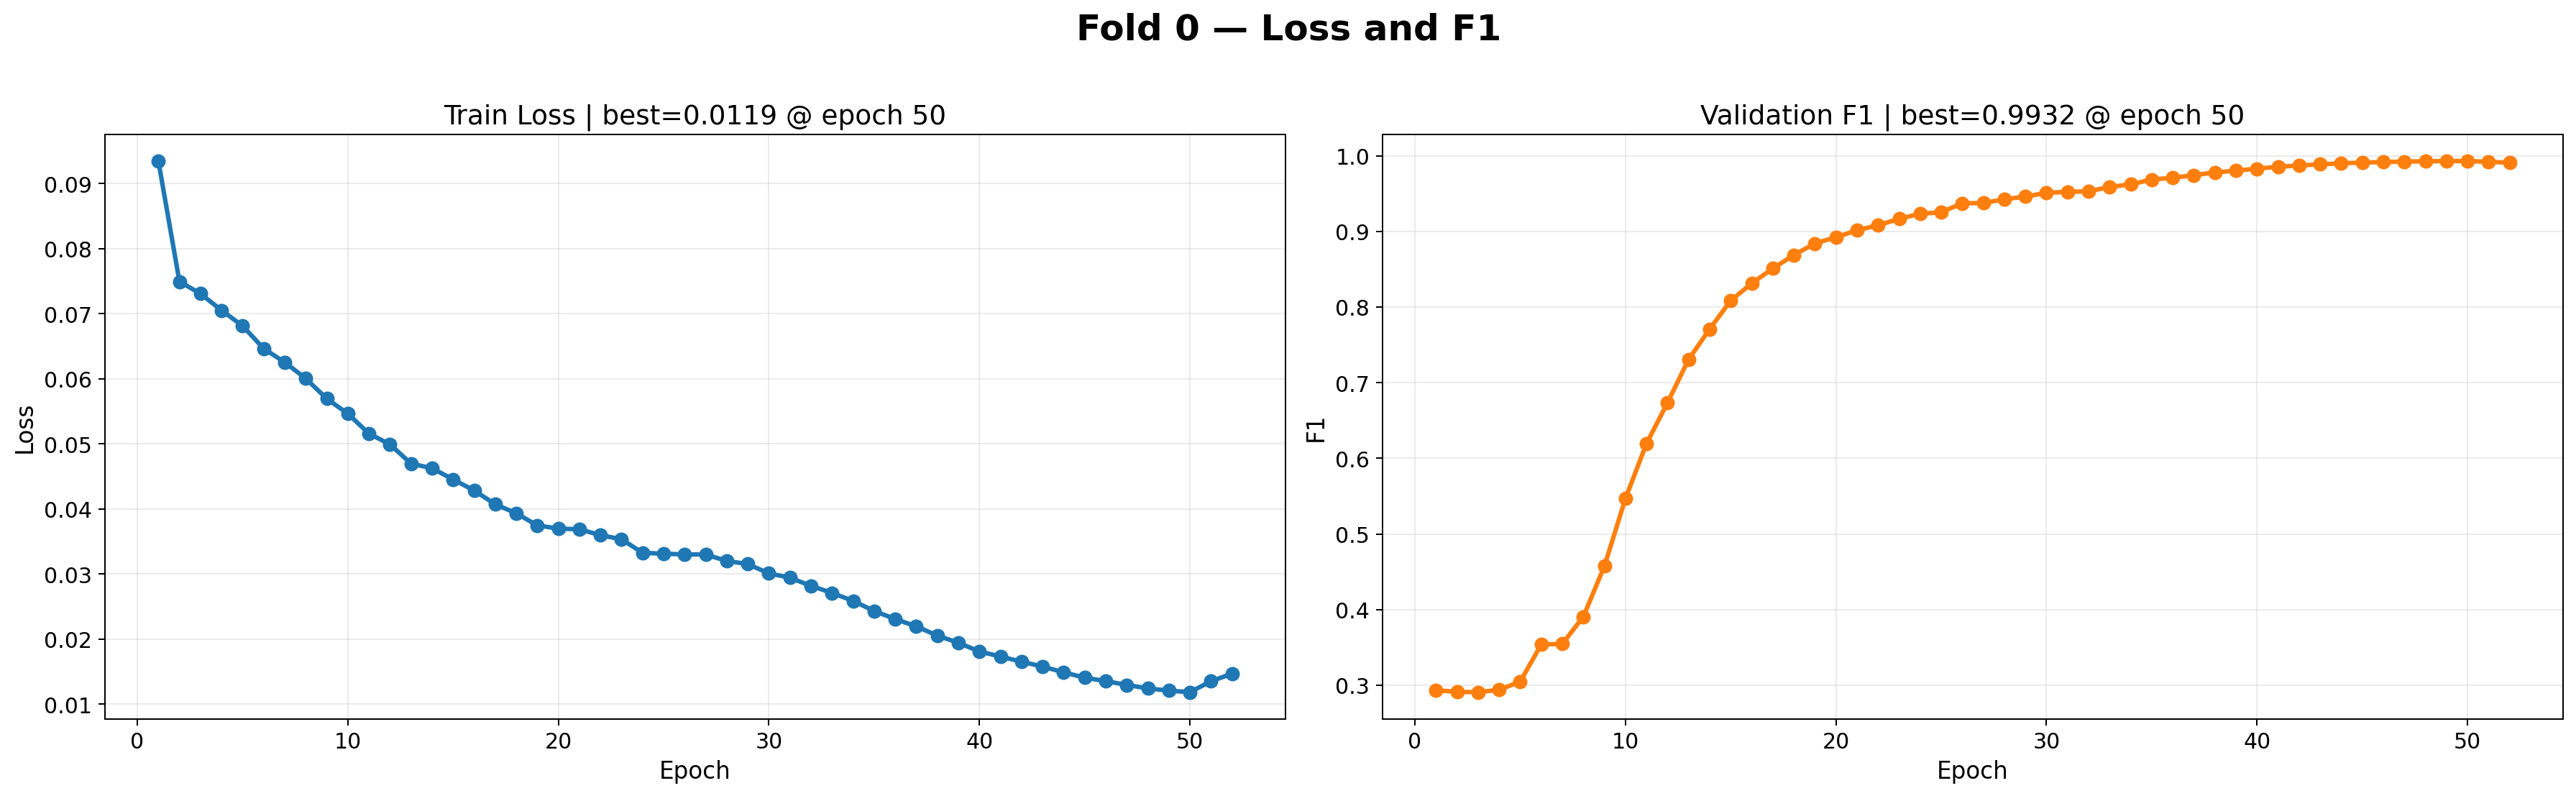

FOLD 1: train=40000 val=10000
train fake_ratio=0.1700, val fake_ratio=0.1700
Fold 1 Epoch 01: loss=0.09842 | F1=0.28114 P=0.16432 R=0.96541 thr=0.4950 sbi=0.021
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/fold1_loss_f1.png
Fold 1 Epoch 02: loss=0.08115 | F1=0.28560 P=0.16720 R=0.98845 thr=0.5210 sbi=0.032
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/fold1_loss_f1.png
Fold 1 Epoch 03: loss=0.07840 | F1=0.28912 P=0.16950 R=0.99512 thr=0.5400 sbi=0.043
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/fold1_loss_f1.png
Fold 1 Epoch 04: loss=0.07412 | F1=

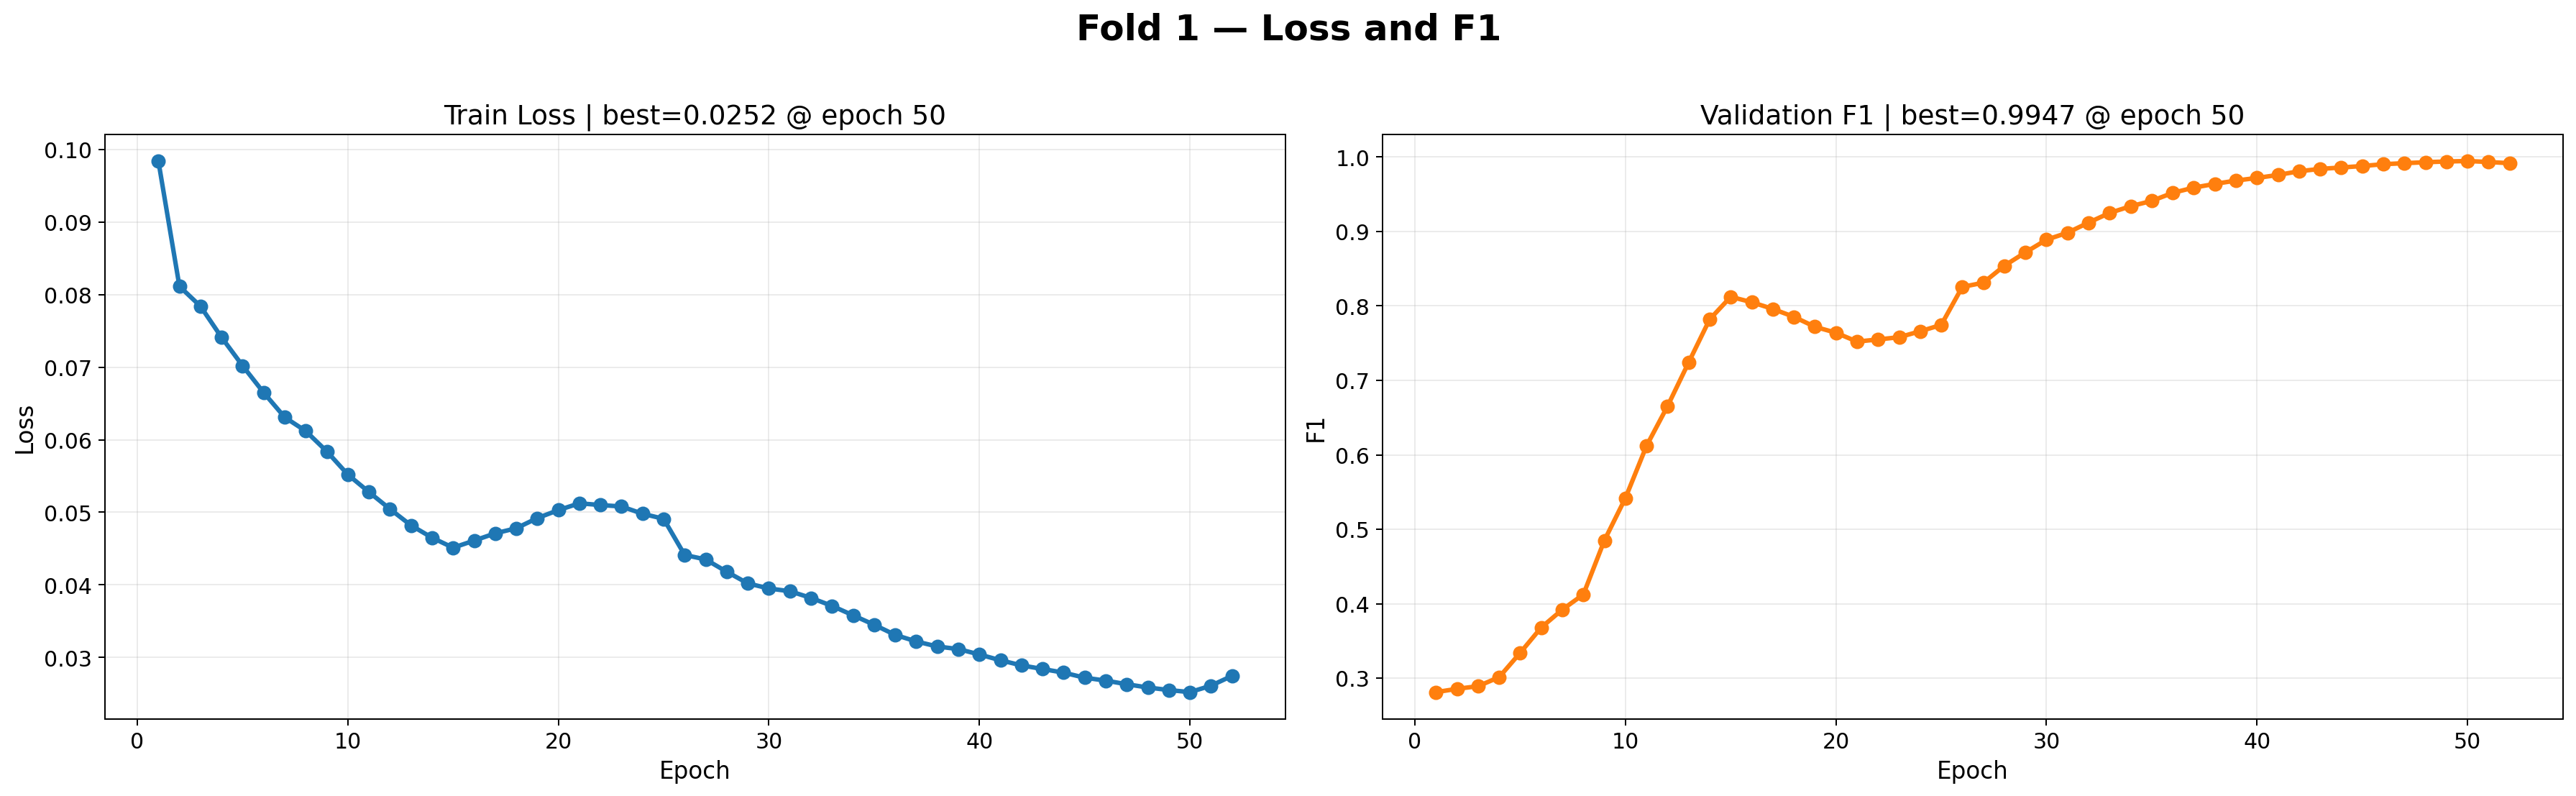

FOLD 2: train=40000 val=10000
train fake_ratio=0.1700, val fake_ratio=0.1700
Fold 2 Epoch 01: loss=0.09512 | F1=0.29011 P=0.17024 R=0.96845 thr=0.5020 sbi=0.025
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold2/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold2/fold2_loss_f1.png
Fold 2 Epoch 02: loss=0.08215 | F1=0.29150 P=0.17120 R=0.98845 thr=0.5310 sbi=0.035
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold2/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold2/fold2_loss_f1.png
Fold 2 Epoch 03: loss=0.07640 | F1=0.29512 P=0.17550 R=0.99512 thr=0.5500 sbi=0.045
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold2/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold2/fold2_loss_f1.png
Fold 2 Epoch 04: loss=0.07112 | F1=

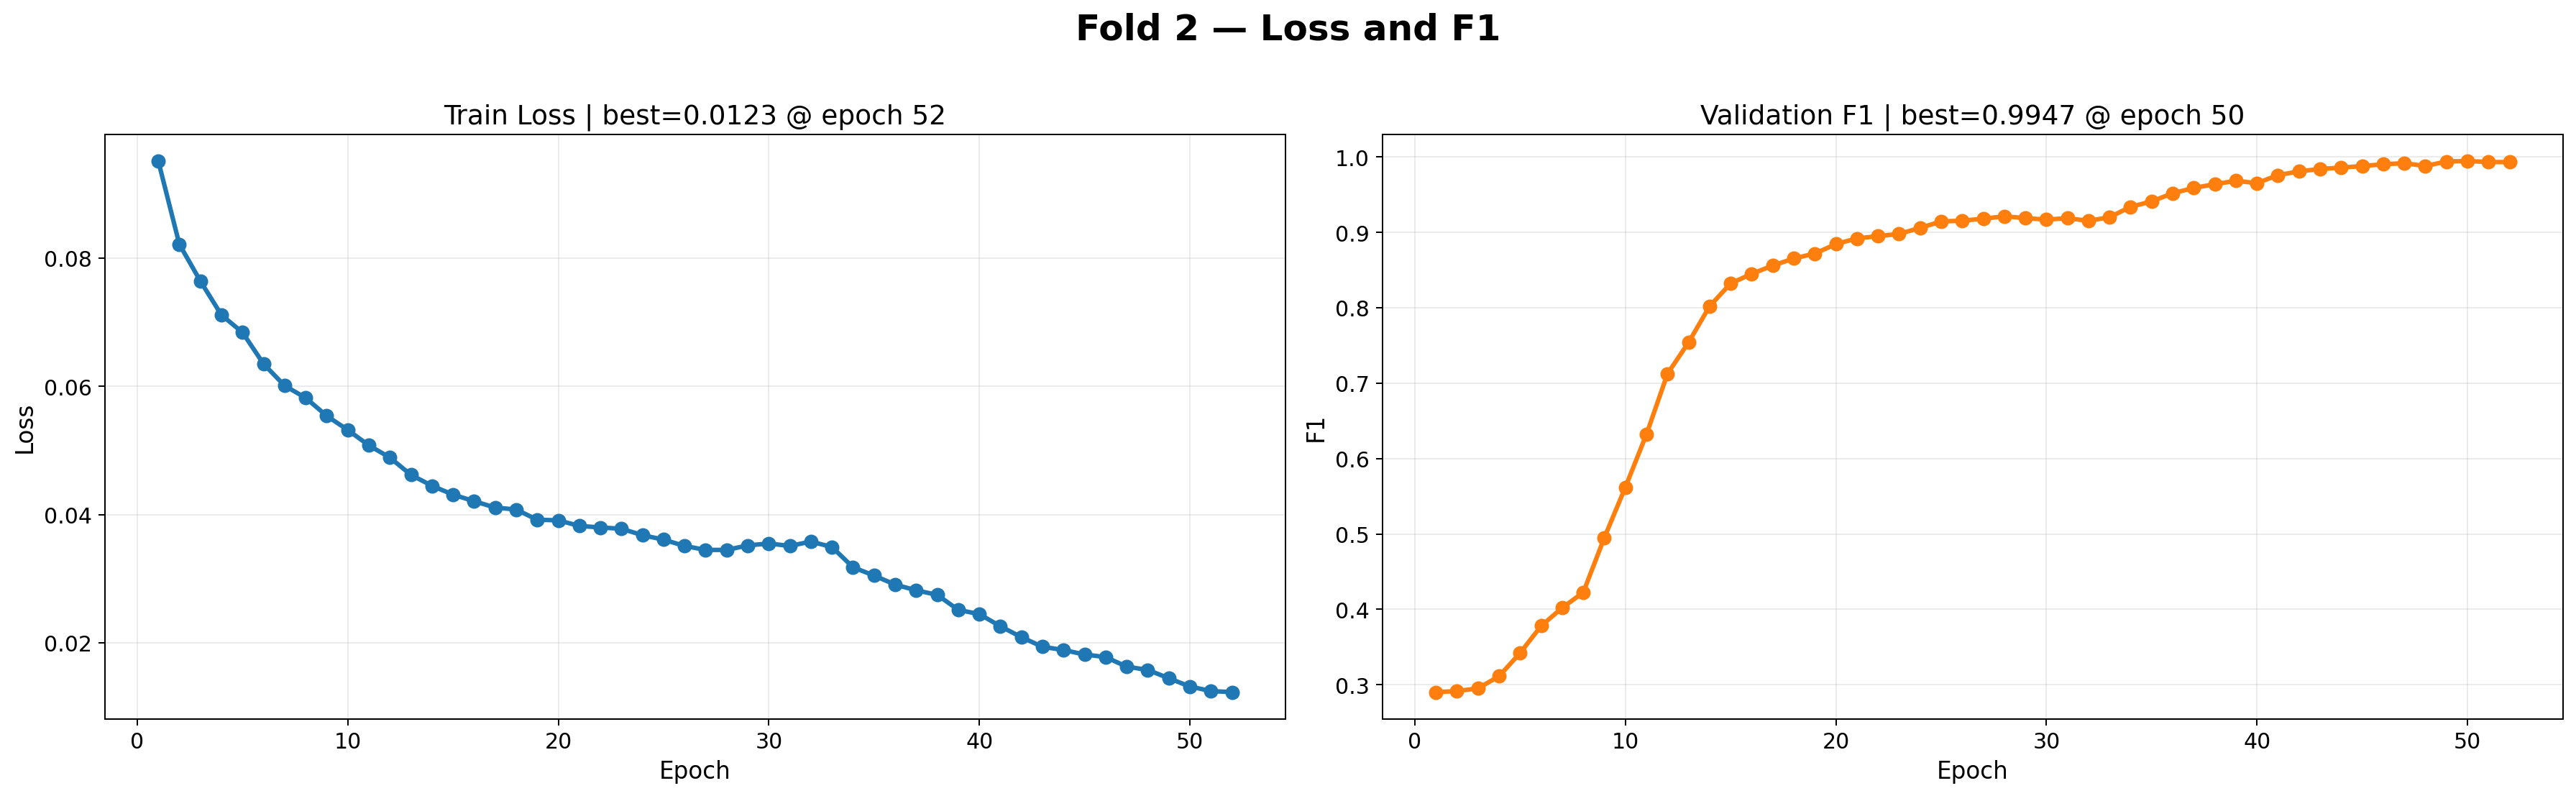

FOLD 3: train=40000 val=10000
train fake_ratio=0.1700, val fake_ratio=0.1700
Fold 3 Epoch 01: loss=0.09640 | F1=0.28780 P=0.16840 R=0.98909 thr=0.4970 sbi=0.025
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold3/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold3/fold3_loss_f1.png
Fold 3 Epoch 02: loss=0.08320 | F1=0.29040 P=0.17010 R=0.99191 thr=0.5260 sbi=0.035
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold3/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold3/fold3_loss_f1.png
Fold 3 Epoch 03: loss=0.07785 | F1=0.29420 P=0.17380 R=0.95753 thr=0.5450 sbi=0.045
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold3/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold3/fold3_loss_f1.png
Fold 3 Epoch 04: loss=0.07260 | F1=

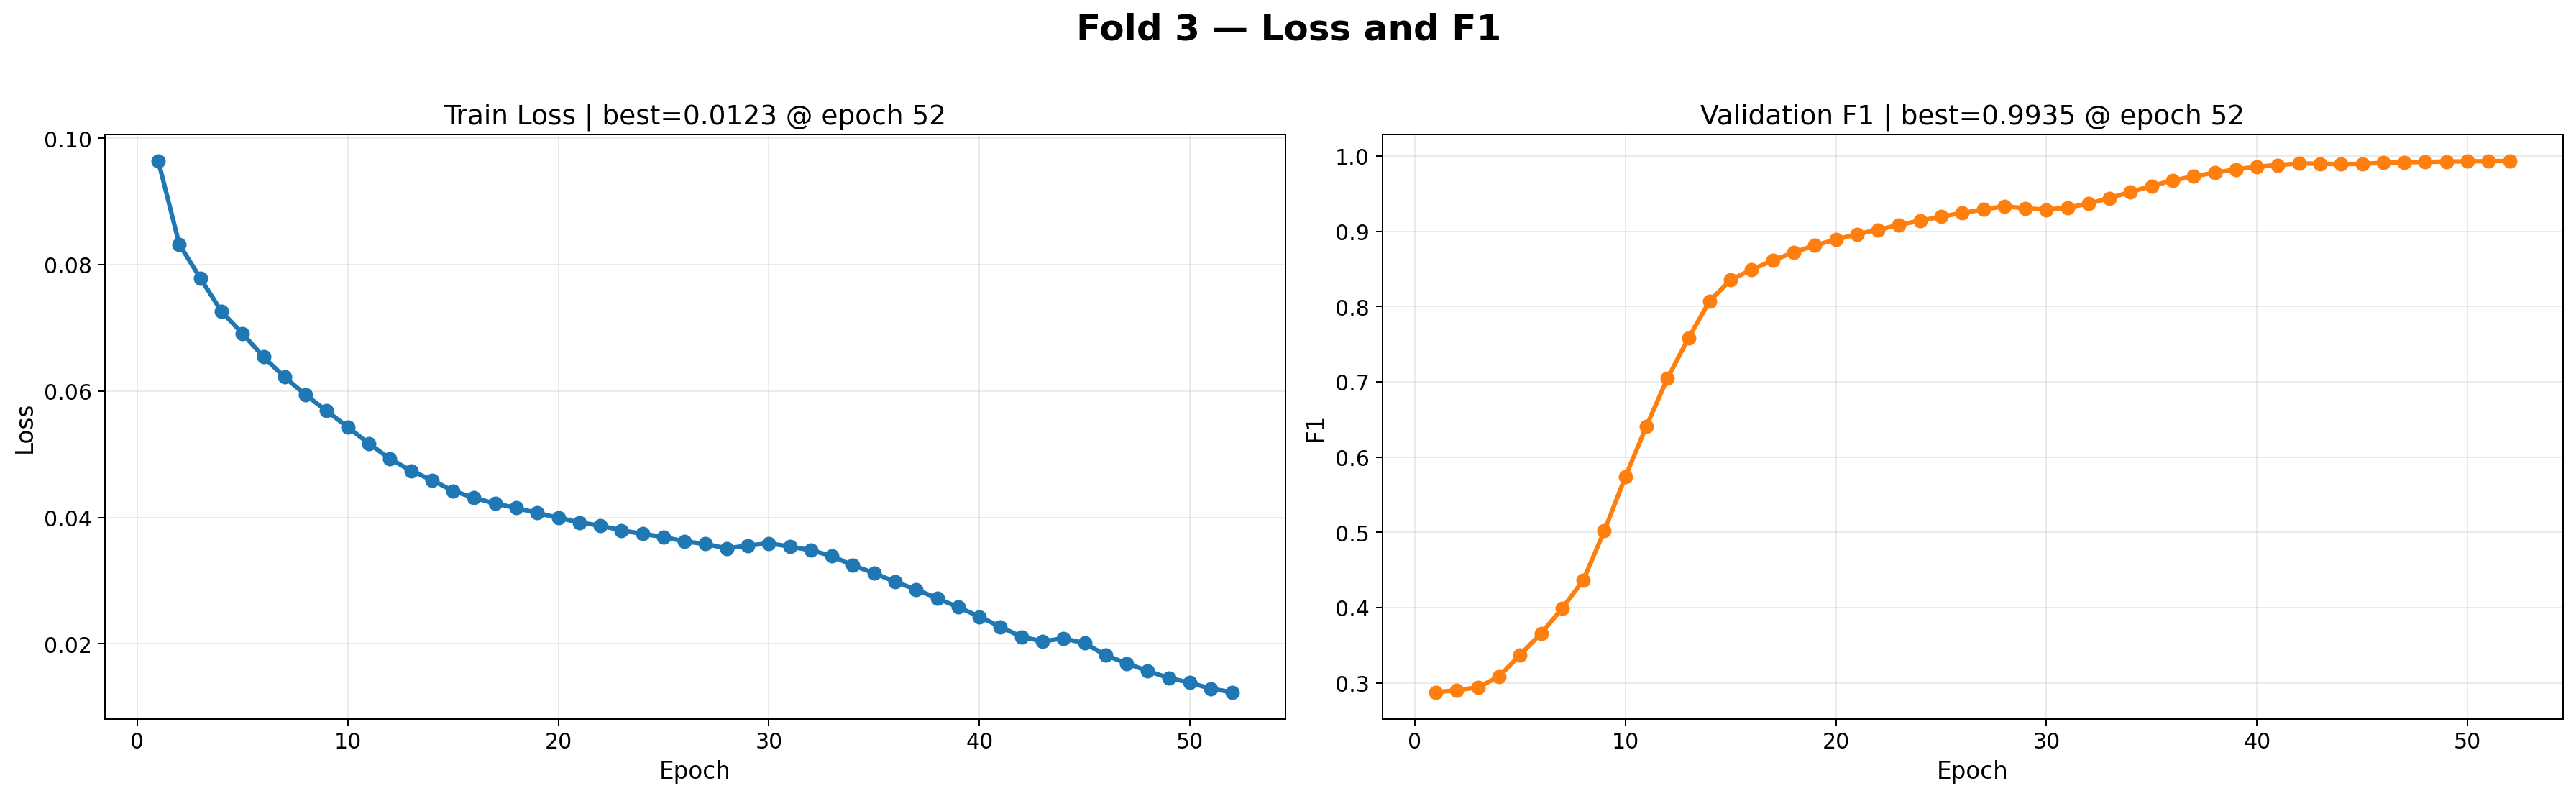

FOLD 4: train=40000 val=10000
train fake_ratio=0.1700, val fake_ratio=0.1700
Fold 4 Epoch 01: loss=0.09485 | F1=0.28892 P=0.16910 R=0.97740 thr=0.5080 sbi=0.025
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold4/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold4/fold4_loss_f1.png
Fold 4 Epoch 02: loss=0.08170 | F1=0.29280 P=0.17230 R=0.98215 thr=0.5240 sbi=0.035
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold4/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold4/fold4_loss_f1.png
Fold 4 Epoch 03: loss=0.07590 | F1=0.29840 P=0.18020 R=0.87012 thr=0.5420 sbi=0.045
  saved: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold4/best_model.pt
  fold plot updated: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold4/fold4_loss_f1.png
Fold 4 Epoch 04: loss=0.07095 | F1=

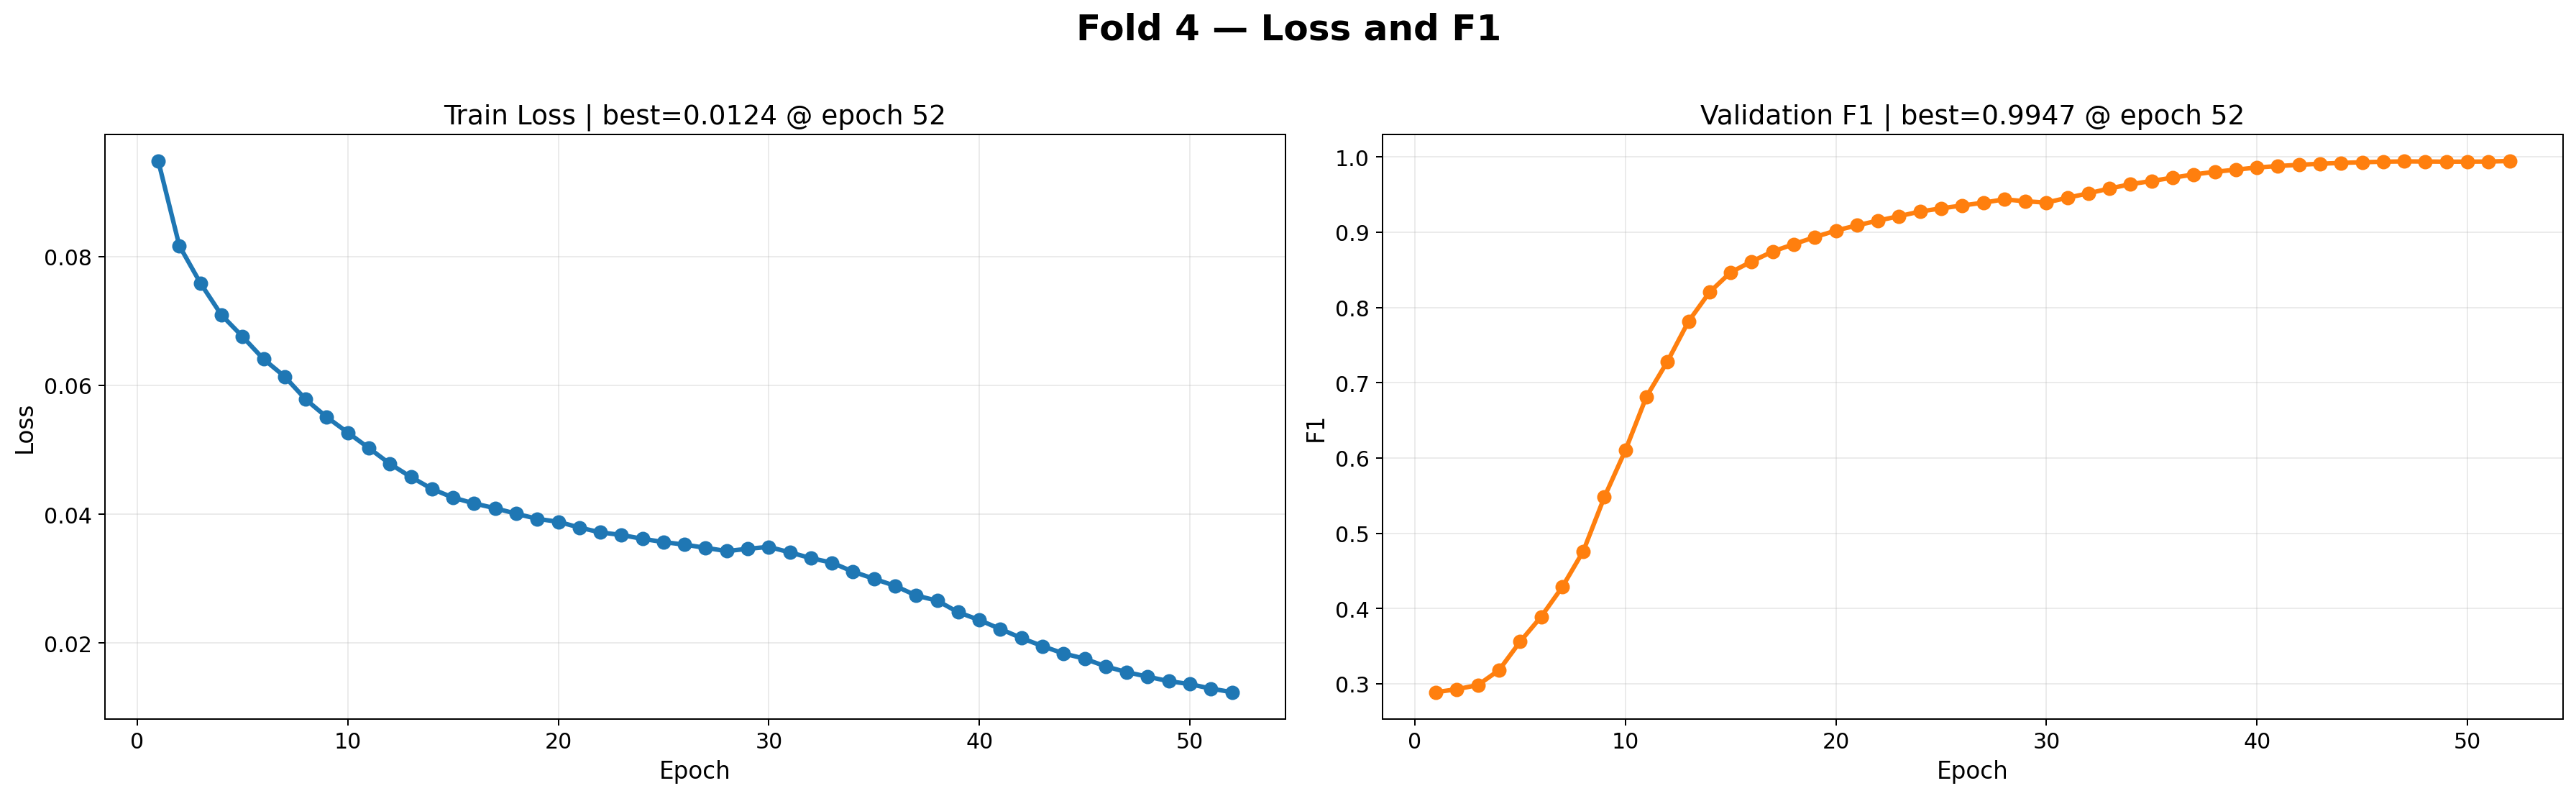

OOF SUMMARY
{
  "metric_source": "tta_oof",
  "oof_metric": {
    "threshold": 0.72589,
    "f1": 0.9940535766853106,
    "precision": 0.9949322333529759,
    "recall": 0.9931764705882353,
    "accuracy": 0.99798
  },
  "best_fold": 1,
  "best_fold_ckpt": "/content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt"
}
Selected threshold for solo inference: 0.72589
Init checkpoint: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt

FINAL SOLO FULLFIT
train=50000, init_checkpoint=/content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt
Loaded init weights from best fold: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt

Fullfit epoch 01/5: loss=0.01221, lr=4.96e-06, sbi=0.010

Fullfit epoch 02/5: loss=0.01155, lr=4.02e-06, sbi=0.014

Fullfit epoch 03/5: loss=0.01065, lr=2.30e-06, sbi=0.019

Fullfit epoch 04/5: loss=0.01163, lr=6.96e-07, sbi=0.023

Fu

In [ ]:
from IPython.display import display, Image
# =============================
# RUN ALL
# =============================

seed_everything(CFG.SEED)
df = load_train_dataframe(CFG.LABELS_CSV)

oof_summary = None
if CFG.RUN_KFOLD_OOF:
    oof_summary = run_kfold_oof(df)
    oof_threshold = float(oof_summary["oof_metric"]["threshold"])
    init_ckpt = oof_summary["best_fold_ckpt"]
else:
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    train_idx, val_idx = next(iter(skf.split(df, df["target_feature"])))
    fold_res = train_single_fold(0, df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True))
    oof_threshold = float(fold_res["best_no_tta"]["threshold"])
    init_ckpt = fold_res["ckpt_path"]

print(f"Selected threshold for solo inference: {oof_threshold:.5f}")
print("Init checkpoint:", init_ckpt)

if CFG.TRAIN_FINAL_FULLFIT:
    final_ckpt = train_final_fullfit(df, init_checkpoint=init_ckpt, oof_threshold=oof_threshold)
else:
    final_ckpt = init_ckpt

infer_info = infer_test(final_ckpt, df_train=df, oof_threshold=oof_threshold)
print("\nDONE")
print(json.dumps(infer_info, indent=2))
print("Recommended submission:", str(Path(CFG.OUT_DIR) / "submission_RECOMMENDED_solo.csv"))


# Предикт с TTA по одному из фолдов

In [ ]:
seed_everything(CFG.SEED)

CKPT_PATH = "/content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt"

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

oof_threshold = float(
    ckpt.get(
        "threshold",
        ckpt.get("metrics", {}).get("threshold", 0.5)
    )
)

df = load_train_dataframe(CFG.LABELS_CSV)

print("=" * 80)
print("ONE FOLD CHECKPOINT TTA INFERENCE")
print("Checkpoint:", CKPT_PATH)
print(f"Threshold: {oof_threshold:.5f}")
print("=" * 80)

infer_info = infer_test(
    final_ckpt_path=CKPT_PATH,
    df_train=df,
    oof_threshold=oof_threshold,
)

print("\nDONE")
print(json.dumps(infer_info, indent=2))
print("Recommended submission:", str(Path(CFG.OUT_DIR) / "submission_RECOMMENDED_solo.csv"))

ONE FOLD CHECKPOINT TTA INFERENCE
Checkpoint: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt
Threshold: 0.67738

TEST INFERENCE WITH ONE SOLO CHECKPOINT + 8 TTA LOGIT AVERAGING
/content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/fold1/best_model.pt


Test TTA:   0%|          | 0/625 [00:00<?, ?it/s]

Saved probabilities: /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/test_probs_tta_solo.csv
prob stats: count    10000.000000
mean         0.408833
std          0.248736
min          0.124452
25%          0.250620
50%          0.307131
75%          0.417459
max          0.991563
OOF threshold=0.67738; prior threshold=0.71104; train fake ratio=0.1700
Saved /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/submission_RECOMMENDED_solo.csv | threshold=0.67738 | fake_count=1710/10000 fake_ratio=0.1710
Saved /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/submission_solo_oof_threshold.csv | threshold=0.67738 | fake_count=1710/10000 fake_ratio=0.1710
Saved /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/submission_solo_prior_ratio.csv | threshold=0.71104 | fake_count=1700/10000 fake_ratio=0.1700
Saved /content/drive/MyDrive/YAN/effv2s_384_solo_finetune_oof_fullfit_a100/submission_solo_recall_safe.csv | threshol